# Стохастический градиентный спуск Часть 1
На занятии по обучению нейронных сетей при работе с моделью, предсказывающей
рукописные цифры, мы столкнулись с двумя сложностями:

1. из-за большого количества наблюдений модель медленно обучалась; и кроме
того
2. уровень ошибки при заданном количестве эпох и скорости обучения снизился
недостаточно, что привело к слабым результатам как на обучающей, так и на
тестовой выборках.

На сегодняшнем занятии мы рассмотрим способы улучшения метода градиентного
спуска. Мы уже начали этот разговор на последнем занятии вводного курса,
отвечая на вопросы про параметр batch-size.
## Терминология и нотация
Вначале договоримся о терминах и нотации. Функция потерь или **целевая функция**  с одним или несколькими параметрами $\theta$ будет обозначаться как
$f(\theta).$ Точку **минимума** такой функции, то есть оптимальные веса, обозначим $\theta^*.$ **Градиент** функции в точке $\theta$ — $\nabla f(\theta).$

**Данны**е поместим в переменные $(X, y)$ для всего набора данных, и $(x_i, y_i)$ —
для отдельных **наблюдений**. Дополнительно заметим, что в литературе по
оптимизации параметры часто обозначают через $x,$ а целевую функцию
соответственно $f(x).$ На данном этапе будем избегать такой нотации, чтобы не
путать параметры и наблюдения.

**Коэффициент скорости обучения** (learning rate) обозначим буквой $\eta$ («эта»);
также заметим, что в литературе по оптимизации $\eta$ называют размером шага
(step size).

Итерации и эпохи (различие станет понятно из последующего изложения) или шаги
в большинстве случаев будем обозначать через надстрочные или подстрочные $k$,
соответственно последующий шаг через $k+1$, а предыдущий $k-1.$

## Методы оптимизации
Сделаем несколько общих замечаний о методах оптимизации. Вспомним, что методы оптимизации могут быть **аналитическими** (например, метод наименьших квадратов) и **численными** (градиентный спуск).

Если численный метод предполагает задание некоторого приближенного решения (*начальное приближение*, $\theta_0$), которое затем улучшается на каждой итерации, то такой метод называется **итерационным** (iterative).

Метод сходится (converges) к оптимальному значению, если

$$ \theta^k \xrightarrow[k \to \infty] \; \theta^* $$

Также заметим, что методы или алгоритмы оптимизации часто называют **оптимизаторами** (optimizers, solvers) [функции потерь]. Например, упомянутые на
вводном курсе метод стохастического градиентного спуска или алгоритм Adam как раз являются примерами оптимизаторов.

Перейдем к теме занятия.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Подготовка данных
В большинстве примеров будем использовать уже знакомую модель
множественной линейной регрессии, а также искусственно созданный
(синтетический, synthetic) набор данных.

Напишем функцию, которая будет создавать такие данные. На вход она будет принимать вектор весов theta (включая сдвиг, $\theta_0$), количество наблюдений n, а также «уровень шума» noise.

In [24]:
def synth_reg_data(theta, n = 1000, noise = 0.01, random_state = 42):
  np.random.seed(random_state)
  # создадим массив данных, следующий нормальному распределению,
  # размерностью: кол-во наблюдений х кол-во признаков без смещения
  X = np.random.normal(size = (n, len(theta)-1))
  # добавим столбец из единиц для смещения
  X = np.c_[np.ones((len(X), 1)), X]
  # создадим нормально распределенный шум
  noise = np.random.normal(size = n) * noise
  # найдем значения целевой переменной
  y = np.dot(X, theta) + noise
  return X, y

Такой подход позволит нам заранее знать оптимальные веса $\theta^{*}.$ Как следствие, мы сможем оценить, как изменяется расстояние от текущих весов до истинных.

In [25]:
# создадим вектор весов (первое значение - сдвиг)
t_true = np.array([3.2, 2, -2.7, 1.6])
# сгенерируем данные
X, y = synth_reg_data(t_true)

Пропишем функцию градиента модели линейной регрессии.

In [26]:
def gradient(x, y, thetas, n):
  return np.dot(x.T, (np.dot(x, thetas) - y)) * (1 / n)

## Работа с наблюдениями
Начнем улучшать алгоритм градиентного спуска, обучая модель на различном
количестве имеющихся наблюдений.

## Full batch

Вначале объявим функцию линейной регрессии, которая будет обновлять веса на основе всех наблюдений. Такой подход называется full batch градиентным
спуском.

На вход функция fit_full_batch() будет принимать:
* массив признаков x и целевую переменную y;
* истинные веса t_opt;
* количество итераций алгоритма iter; и
* коэффициент скорости обучения lr.

In [27]:
def fit_full_batch(x, y, t_opt, iter = 100000, lr = 0.01):

  x, y = x.copy(), y.copy()
  # создадим вектор весов с нулевыми значениями и
  # узнаем количество наблюдений
  thetas, n = np.zeros(x.shape[1]), x.shape[0]
  # создадим список для учета расстояния до оптимальных весов
  dist_to_opt = []

  # в процессе обучения
  for i in range(iter):
    # будем рассчитывать евклидово расстояние до оптимума
    dist_to_opt.append(np.linalg.norm(thetas - t_opt))
    # рассчитаем градиент
    grad = gradient(x, y, thetas, n)
    # и обновим веса
    thetas = thetas - lr * grad

  return dist_to_opt

Еще раз заметим, что с помощью цикла мы обновляем веса iter раз, каждый раз рассчитывая градиент на ***всех*** данных. Обучим модель.

In [28]:
dist_fb = fit_full_batch(X, y, t_true)

Посмотрим на изменение расстояния до оптимума.

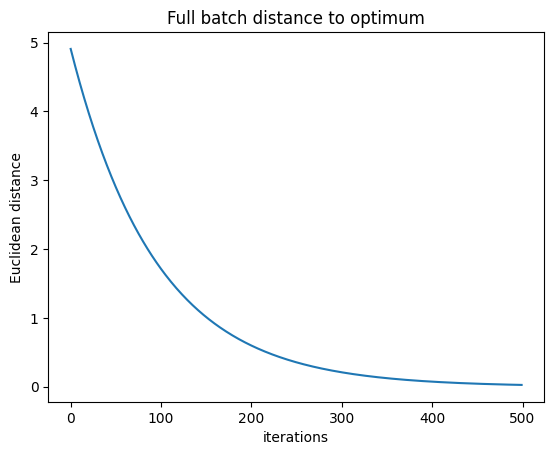

In [29]:
plt.plot(dist_fb[:500])
plt.title('Full batch distance to optimum')
plt.xlabel('iterations')
plt.ylabel('Euclidean distance');

Как и должно быть, ошибка постоянно и плавно снижается, однако время выполнения кода даже на небольшом наборе данных остаточно существенное.

Математически этот подход можно описать через задачу минимизации
относительно $\theta$ конечного множества гладких (непрерывно
дифференцируемых) функций потерь

$$ \underset{\theta}{\min} f(\theta) = \underset{\theta}{\min} \frac{1}{n} \sum^n_{i=1}
f_i (\theta), $$

где каждая $f_i (\theta)$ определяет ошибку для конкретного наблюдения $x_i$. Для
линейной регрессии речь идет о

$$ f_i (\theta) = (y_i-\theta x_i)^2 $$

Усредненная сумма этих ошибок и будет показывать уровень ошибки при текущих
весах на имеющихся данных. В таком случае градиентный спуск в общем виде
можно определить так

$$ \theta^{k+1} := \theta^{k}-\eta \cdot \nabla f (\theta^{k}) $$

или так

$$ \theta^{k+1} := \theta^{k}-\eta \cdot \frac{1}{n} \sum^n_{i=1} \nabla f_i (\theta^{k})
$$

для шагов $k = 1, 2, 3, \ldots$
Сложность full batch подхода опять же заключается в том, что расчет градиента на
всех наблюдениях вычислительно затратен.

### SGD и Mini batch
Попробуем решить задачу минимизации не на всех, а только на одном случайно выбранном наблюдении. В этом случае говорят о **стохастическом** градиентном спуске (stochastic gradient descent или SGD).

Более формально,

$$ \theta^{k+1} := \theta^{k}-\eta \cdot \nabla f_{i_k} (\theta^{k}), \quad k = 1, 2, 3,
\ldots, $$

и $i_k \in \{ 1, \ldots, n \}$ — случайно выбранный индекс наблюдения на шаге $k.$

Такой алгоритм будет в $n$ раз быстрее, чем обычный градиентный спуск, однако возникает вопрос, будет ли он стремиться к оптимальным параметрам $\theta^{*}.$
### SGD как несмещенная оценка градиента
Интересно, что хотя спуск в точку минимума очевидно не будет таким плавным,
как при full batch подходе (ведь каждый раз мы вычисляем градиент на разных
данных), тем не менее на каждом шаге $k$ матожидание стохастического
градиентного спуска (для одного наблюдения) $\mathbb{E} [\nabla f_{i_k} (\theta)]$
является несмещенной оценкой (unbiased estimate) full batch градиента $ \nabla
f(\theta).$

$$ \mathbb{E} [\nabla f_{i_k} (\theta)] = \nabla f(\theta) $$

Разберем это утверждение более подробно. Начнем с того, что несмещенной
оценкой называется такая точечная оценка (т.е. число, а не диапазон) некоторого

параметра $\theta$, матожидание которого равно этому параметру
$$ \mathbb{E} [ \hat{\theta} ] = \theta, \quad \forall \theta \in \Theta $$

или, что то же самое, $ \mathbb{E} [ \hat{\theta} ]-\theta=0. $ Если же эта разность не
равна нулю, то такая величина называется смещением (bias).

$$ \mathbb{E} [ \hat{\theta}-\theta] = \mathbb{E} [ \hat{\theta} ]-\mathbb{E} [ \theta ] =
\mathbb{E} [ \hat{\theta} ]-\theta $$

Далее, по определению математическое ожидание есть средневзвешенная по
вероятностям $p_i$ возможных значений $x_i$ оценка случайной величины

$$ \mathbb{E}[X] = \sum^{\infty}_{i=1} p_i x_i $$

В случае стохастического градиентного спуска с учетом одинаковой $\frac{1}{n}$
вероятности каждого наблюдения матожидание равно

$$ \mathbb{E} [ \nabla f_{i_k}(\theta) ] = \sum^n_{i=1} \frac{1}{n} \nabla f_i (\theta) = \frac{1}{n} \sum^n_{i=1} \nabla f_i (\theta) = \nabla f(\theta) $$

### Mini batch подход
Компромиссом между плавностью спуска и затратами вычислительных ресурсов
является использование лишь части (batch) наблюдений или mini batch подход.
При таком подходе случайным образом выбирается подмножество $ I_k \subseteq \{
1, \ldots, n \} $ мощностью $|I_k| = b << n.$

$$ \theta^{k+1} := \theta^{k}-\eta \cdot \frac{1}{b} \sum_{i_k \in I_k} \nabla f_{i_k}
(\theta^{k}), \quad k = 1, 2, 3, \ldots $$

Поскольку $ \mathbb{E}[\frac{1}{b} \sum_{i \in I_k} \nabla f_{i_k} (\theta) ] = \nabla
f(\theta) $, матожидание mini batch подхода также будет несмещенной оценкой full
batch градиента.

Реализуем эти алгоритмы в коде.

#### Деление данных на batches
Начнем с функции, которая будет делить наблюдения на batches.

In [30]:
def create_batches(X, y, batch_size, random_state = 42):

  # создадим список, в который будем помещать batches
  mini_batches = []

  # присоединим целевую переменную "справа" от признаков
  data = np.hstack((X, y.reshape((-1, 1))))

  # перемешаем данные случайным образом
  np.random.seed(random_state)
  np.random.shuffle(data)

  # определим количество полных batches
  n_minibatches = data.shape[0] // batch_size

  # если остается неполная batch,
  # увеличиваем общее количество на 1
  if data.shape[0] % batch_size != 0:
    n_minibatches += 1

  # в цикле, равном количеству batches,
  for i in range(n_minibatches):
    # делим наблюдения на mini batches
    mini_batch = data[i * batch_size : (i + 1) * batch_size, :]
    # разделяем признаки и
    X_mini = mini_batch[:, :-1]
    # целевую переменную
    y_mini = mini_batch[:, -1]
    # добавляем эти части в список mini_batches
    mini_batches.append((X_mini, y_mini))

  return mini_batches

Протестируем функцию. Разделим данные на batches по 16 наблюдений в каждой.

С учетом того, что у нас всего 1000 наблюдений, то должно получиться $1000 \div
16 = 63$ полных и неполных batches, из которых 62 будут содержать по 16
наблюдений, а в последней будет $1000-(62 \times 16) = 8.$

In [31]:
# разделим данные на batches по 16 наблюдений
mb_16 = create_batches(X, y, batch_size = 16)

# выведем
# 1. количество batches (полные + неполная, если есть)
# 2. размер полной batch
# 3. размер неполной (последней) batch

len(mb_16), len(mb_16[-2][0]), len(mb_16[-1][0])

(63, 16, 8)

Если же мы хотим реализовать стохастический градиентный спуск, то batch_size
должен быть равен единице.

In [32]:
# подготовим наблюдения для SGD
mb = create_batches(X, y, batch_size = 1)
len(mb), len(mb[-2][0]), len(mb[-1][0])

(1000, 1, 1)

### Про особенность реализации в коде
Заметим, что при делении данных на batches мы перемешивали данные случайным образом с помощью функции **np.random.shuffle()** , а затем поочередно брали то количество , которое определялось параметром batch_size. Другими словами, мы
выбирали данные без возвращения.

Такой подход нарушает одинаковую вероятность каждого наблюдения $\frac{1}
{n},$ а значит не обеспечивает несмещенности оценки стохастического
градиентного спуска.

$$ \mathbb{E} [ \nabla f_{i_k}(\theta) ] \not= \nabla f(\theta) $$

Это связано с тем, что выборка без возращения делает события (вероятность
выбрать одно наблюдение) зависимыми. Рассмотрим простой пример.

Пусть перед нами две урны $^{(1)}$ и $^{(2)}.$ В каждой 7 белых $(w)$ и 3 черных
$(b)$ шара. Из первой урны мы будем доставать шары с возвращением, из второй
— без.

Найдем вероятность достать белый шар на первом шаге $(w_1).$ Для обеих урн
вероятность будет одинаковой.

$$ P^{(1)}(w_1) = \frac{7}{10} \quad \quad P^{(2)}(w_1)= \frac{7}{10} $$

Предположим, что мы действительно достали белый шар. Какой будет вероятность
достать черный шар на втором шаге $b_2?$ По правилу совместной вероятности
независимых событий для первой урны получим

$$ P^{(1)}(w_1, b_2) = P^{(1)}(w_1) \cdot P^{(1)}(b_2) = \frac{7}{10} \cdot \frac{3}
{10} = 0{,}21 $$

В случае второй урны события зависимы. Другими словами, вероятность достать
черный шар на втором шаге зависит от первого события, то есть белого шара,
$P^{(2)}(b_2 \mid w_1),$ и такая вероятность равна $\frac{3}{9}$ (в урне
по-прежнему три черных шара, но всего шаров теперь только девять).

Совместная вероятность зависимых событий, таким образом, будет равна

$$ P^{(2)}(w_1, b_2) = P^{(2)}(w_1) \cdot P^{(2)}(b_2 \mid w_1) = \frac{7}{10} \cdot
\frac{3}{9} \approx 0{,}23 $$

Говоря о реализации SGD в коде, хотя подход с перемешиванием (выборки без возвращения) и нарушает математическое обоснование этого алгоритма, тем не менее применяется на практике, поскольку требует меньших ресурсов, чем
случайный выбор одного элемента $i_k$ или подмножества $I_k$ из $n$ наблюдений на каждом шаге $k.$

### Сравнение SGD и mini batch
Обучим модель методом стохастического градиентного спуска и с использованием
mini batch. Основное отличие от full batch подхода — у нас появляется два цикла:
* эпохи (epochs), за каждую из которой алгоритм должен «просмотреть» все
данные;
* batches, после оценки которой стохастический градиентный спуск обновляет
веса.

In [33]:
def fit_sgd(x, y, t_opt, batch_size, epochs = 50, lr = 0.01):

  x, y = x.copy(), y.copy()
  thetas = np.zeros(x.shape[1])

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      grad = gradient(x_b, y_b, thetas, n)
      thetas = thetas - lr * grad

  return dist_to_opt

In [34]:
dist_sgd = fit_sgd(X, y, t_true, batch_size = 1, epochs = 100)

Если количество эпох равно 100, а количество batches 1000 (по одному наблюдению
в каждой), то всего алгоритм обновит веса 100000 раз.

In [35]:
len(dist_sgd)

100000

Посмотрим, как менялось расстояние до оптимума.

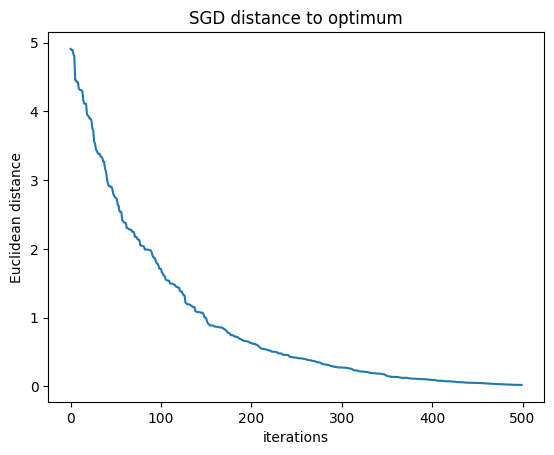

In [36]:
plt.plot(dist_sgd[:500])
plt.title('SGD distance to optimum')
plt.xlabel('iterations')
plt.ylabel('Euclidean distance');

Как мы видим, присутствуют скачки градиента (и как следствие, расстояния до
оптимума). Попробуем увеличить размер партии до 32 наблюдений.

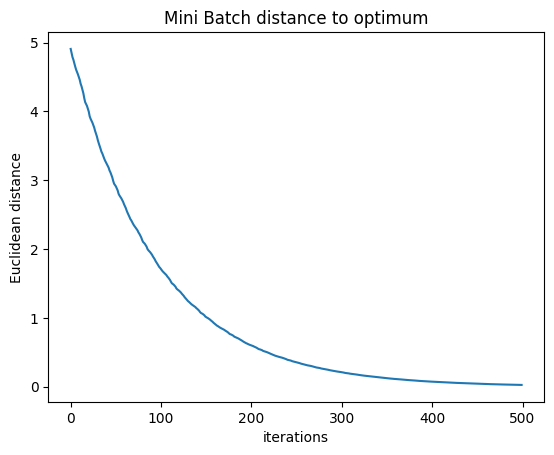

In [37]:
plt.plot(fit_sgd(X, y, t_true, batch_size = 32, epochs = 3125)[:500])
plt.title('Mini Batch distance to optimum')
plt.xlabel('iterations')
plt.ylabel('Euclidean distance');

Колебания уменьшились, но не исчезли. Возникает вопрос, можно ли сохранить
быстроту стохастического спуска и при этом уменьшить дисперсию.

### SVRG

**SVRG** (Stochastic Variance Reduced Gradient) или метод градиентного спуска с
уменьшенной дисперсией так же, как и обычный стохастический градиентный
спуск рассчитывает градиент для одного наблюдения $\nabla f_{i_k} (\theta).$

Особенность заключается в том, что шаги разбиты на два вложенных цикла: внешний (outer) и внутренний (inner). В начале каждой итерации внешнего цикла:
* алгоритм запоминает текущие веса $\hat{\theta}$ (theta_hat) и на их основе
делает снимок (snapshot) всего градиента $\nabla f (\hat{\theta})$ (g_hat); затем
* случайным образом берет одно наблюдение $x_i$, рассчитывает
соответствующий градиент $\nabla f_{i_k} (\theta)$; и
* вычитает из него разницу между градиентом $\nabla f_i (\hat{\theta})$ и общим градиентом $\nabla f (\hat{\theta})$.

$$ \theta^{k+1} := \theta^{k}-\eta \left[ \nabla f_{i_k} (\theta^{k})-(f_i (\hat{\theta})-
\nabla f (\hat{\theta})) \right] $$

Таким образом, отличие от SGD состоит в компоненте $(\nabla f_i (\hat{\theta})-
\nabla f (\hat{\theta}))$, который снижает дисперсию стохастического градиента
$f_{i_k} (\theta)$ и, хотя и требует дополнительных вычислений, оказывается
намного быстрее, чем обычный full batch градиентый спуск.

Более того, поскольку

$$\mathbb{E}[\nabla f_i (\hat{\theta})-\nabla f (\hat{\theta})] = \mathbb{E}[\nabla f_i
(\hat{\theta})]-\mathbb{E}[\nabla f (\hat{\theta})] $$

$$ = \nabla f(\hat{\theta})-\nabla f (\hat{\theta}) = 0 $$

то справедливо, что

$$ \mathbb{E} \left[ \nabla f_{i_k} (\theta^{(k)})-(f_i (\hat{\theta})-\nabla f
(\hat{\theta})) \right] = \nabla f (\theta) $$

Другими словами, матожидание SVRG на каждом шаге также является
несмещенной оценкой full batch градиента $\nabla f (\theta)$.

Реализуем алгоритм на Питоне.

In [38]:
# для svrg потребуется функция расчета градиента,
# не усредняющая градиент на количество наблюдений
def svrg_gradient(x, y, thetas):
  return np.dot(x.T, (np.dot(x, thetas) - y))

def fit_svrg(x, y, t_opt, outer_n = 100, inner_n = 100, lr = 0.006, random_state = 42):

  x, y = x.copy(), y.copy()
  thetas, n = np.zeros(x.shape[1]), x.shape[0]
  dist_to_opt = []
  np.random.seed(random_state)

  # на каждой итерации внешнего цикла
  for outer in range(outer_n):
    # делаем снимок текущих весов
    theta_hat = thetas

    # и на их основе рассчитываем общий градиент для всех наблюдений
    g_hat = np.zeros(x.shape[1])
    for i in range(n):
      # берем каждое (!) наблюдение
      xi = x[i,:]
      yi = y[i]
      # рассчитываем градиент для этого наблюдения
      # суммируем все градиенты и получаем общий градиент
      g_hat = g_hat + svrg_gradient(xi, yi, theta_hat)
    # усредняем на количество наблюдений
    g_hat = g_hat / n

    # на каждой итерации внутреннего цикла
    for inner in range(inner_n):
      # берем любое (!) наблюдение с одинаковой вероятностью
      i = np.random.randint(n)
      x_i = x[i,:]
      y_i = y[i]

      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      # рассчитываем градиент и
      grad = (svrg_gradient(x_i, y_i, thetas) - (svrg_gradient(x_i, y_i, theta_hat) - g_hat))
      # обновляем веса
      thetas = thetas - lr * grad

  return dist_to_opt

Пойдем дальше.

## Инерция
Помимо обучения алгоритма на варьирующемся количестве имеющихся
наблюдений, снизить дисперсию можно через использование не только текущего, но и прошлых значений градиента.

### SGD с инерцией

#### Физический контекст
Если представить, что вектор весов — это шарик, который скатывается по склону функции потерь, то в каждый последующий момент времени $k+1$ на него будет действовать не только направление градиента на шаге $k$, как в классическом
SGD, но и градиент предыдущих шагов, называемый инерцией (momentum, $m^{k-1}$) или вектором скорости (velocity, $v^{k-1}$).

Отсюда и название алгоритма SGD с инерцией (with momentum) или SGDm.
![](https://drive.google.com/uc?export=view&id=11k2INAjKDV3Nal83klOC0DlZcb31R9KK)

Другими словами, веса обновляются под воздействием вектора скорости $v^{k-1},$
скорректированного на величину текущего градиента $ \nabla f_{i} (\theta^{k}).$

$$ v^{k} = \beta v^{k-1} + (-\eta \nabla f_{i} (\theta^{k}))$$

$$ \theta^{k+1} := \theta^{k}+v^{k}, $$

где $\beta$ — гиперпараметр, определяющий значимость предыдущих градиентов.
И действительно, на графике выше видно, что вектор $v^{k+1}$ является суммой
векторов $\beta v^{k}$ и $-\eta \nabla f_{i} (\theta^{k}).$

***Примечание.*** В этом разделе мы упростили нотацию $\nabla f_{i_k} (\theta^{k}) \Rightarrow \nabla f_{i} (\theta^{k}).$

Этот же процесс можно записать и так

$$ \theta^{k+1} := \theta^{k}-\eta \nabla f_{i} (\theta^{k})+\beta \underbrace{(\theta^k-
\theta^{k-1})}_{v^{k-1}} $$

### Экспоненциальное сглаживание
Одновременно SGDm можно объяснить через экспоненциальное сглаживание
(экспоненциально взвешенное скользящее среднее, EWMA), которое используется,
в частности, в анализе временных рядов. Рассмотрим следующую рекурсивную
функцию

$$ v_t = \beta \underbrace{v_{t-1}}_{\text{trend}} + (1-\beta)
\underbrace{\theta_t}_{\text{current}}, $$

где параметр $\beta$ распределяет значимость между предыдущими $v_{t-1}$
(trend) и текущим $\theta_t$ (current) наблюдением. При этом, чем больше $\beta$,
тем большее значение отдается предыдущим наблюдениям.

Формулу SGDm также записывают следующим образом.

$$ v^{k} = \beta v^{k-1} + (1-\beta) \nabla f_{i} (\theta^{k}) $$

$$ \theta^{k+1} := \theta^{k}-\eta v^{k} $$

В такой нотации становится очевидным, что $v^{k}$ является экспоненциально
взвешенным скользящим средним между текущим значением $ \nabla f_{i}
(\theta^{k}) $ и прошлыми градиентами $ v^{k-1} $.

Рассмотрим вопрос выбора $\beta.$

#### Выбор $\beta$

При $\beta = 0$ речь очевидным образом идет об обычном стохастическом градиентном спуске. Для того чтобы оценить влияние предыдущих градиентов при $\beta > 0$, выпишем первые несколько членов приведенной выше рекурсивной
формулы временного ряда.

В качестве начального значения положим $v_0 = 0.$

$$ \begin{array}{ll} v_0 & = 0 \\ {\color{Orange} v_1 } & = \beta v_0 + (1-\beta)
\theta_1 = {\color{Orange} (1-\beta) \theta_1} \\ {\color{Plum} v_2} & = \beta
{\color{Orange} v_1} + (1-\beta) \theta_2 = \beta ({\color{Orange} (1-\beta) \theta_1}) +
(1-\beta) \theta_2 \\ & = {\color{Plum} (1-\beta) (\theta_2 + \beta \theta_1)} \\ v_3 & =
\beta {\color{Plum} v_2} + (1-\beta) \theta_3 \\ & = \beta ( {\color{Plum} (1-\beta)
(\theta_2 + \beta \theta_1)} ) + (1-\beta) \theta_3 \\ & = (1-\beta) (\theta_3 + \beta \theta_2
+ \beta^2 \theta_1) \end{array} $$

Поскольку более ранние наблюдения $\theta$ умножаются на $\beta < 1$,
возведенные в возрастающую степень, то их значение или вес со временем
уменьшается. Например, на шаге $v_2$ значение первого наблюдения равно $\beta
\theta_1$, а на шаге $v_3$ уже $\beta^2 \theta_1.$

Приведем общую формулу.

$$ v_t = (1-\beta) \sum^t_{i=0} \beta^{t-i} \theta_i $$

На практике значение $\beta$ часто выбирается равным 0,9. Изучим, как выбор
конкретного $\beta$ влияет на значимость $t$ предыдущих наблюдений $\theta$.
Примем без доказательства, что

$$ \lim_{x \to 0} (1-x)^\frac{1}{x} = \frac{1}{e} $$

Положим $1-x = \beta$, тогда

$$ \lim_{\beta \to 1} \beta^{\frac{1}{1-\beta}} = \frac{1}{e} $$

Заметим, что вес $\beta^t$ определяет значимость слагаемого на шаге $t$. Если
допустить $ \beta^t = \beta^{\frac{1}{1-\beta}} $, то

$$ t = \frac{1}{1-\beta}, \quad \lim_{\beta \to 1} \beta^{t} = \frac{1}{e} $$

Другими словами, подставляя различные значения $\beta$ в $ t = \frac{1}{1-\beta}, $
мы можем определить, на каком шаге $t$ вес наблюдения $\beta^t$ приблизится в
пределе к $\frac{1}{e} \approx 0{,}368$. Например, при $\beta = 0{,}9$, вес,
приблизительно равный $\frac{1}{e}$ будет относиться к $t = \frac{1}{1-\beta} =
\frac{1}{1-0{,}9} = 10$-ому шагу.

И действительно,

$$ \begin{array}{ll} \beta^t = 0{,}9^9 & \approx 0{,}387 \quad \quad & > \frac{1}{e} \\
\beta^t = 0{,}9^{10} & \approx 0{,}349 \quad \quad &\approx \frac{1}{e} \\ \beta^t =
0{,}9^{11} & \approx 0{,}314 \quad \quad & < \frac{1}{e} \end{array} $$

Если же взять другое значение $\beta = 0{,}95$, то соответствующий вес будет
получен на $t = \frac{1}{1-0{,}95} = 20$-ом шаге. Проверим.

$$ \begin{array}{ll} \beta^t = 0{,}95^{19} & \approx 0{,}377 \quad \quad & > \frac{1}
{e} \\ \beta^t = 0{,}95^{20} & \approx 0{,}358 \quad \quad &\approx \frac{1}{e} \\
\beta^t = 0{,}95^{21} & \approx 0{,}341 \quad \quad & < \frac{1}{e} \end{array} $$

Обратим внимание, при $\beta \to 1$ значение $\beta^t$ действительно
приближается к $\frac{1}{e}$. При $\beta = 0{,}99,$

$$ t = \frac{1}{1-0{,}99} = 100, \quad \beta^t = 0{,}99^{100} = 0{,}366 $$

Для чего нужны эти расчеты? На практике, веса, меньшие, чем $\frac{1}{e}$ не
имеют большого значения при расчете текущего значения $\theta$ и соответственно
с помощью $ t = \frac{1}{1-\beta} $ можно понять, сколько предыдущих $t$ шагов в
наибольшей степени влияют на текущее наблюдение.

Приведем расчет количества значимых шагов $t$ для некоторых $\beta.$

$$ \begin{array}{c} \hline \beta \quad & \text{|| } & 0{,}5 & 0{,}8 & 0{,}9 & 0{,}95 &
0{,}98 & 0{,}99 \\ \hline t=\frac{1}{1-\beta} \quad & \text{|| } & 2 & 5 & 10 & 20 & 50
& 100 \\ \hline \end{array} $$

#### Реализация на Питоне
Вернемся к стохастическому градиенту с инерцией и реализуем алгоритм SGDm на Питоне. Одновременно посмотрим, как различные значения $\beta$ влияют на сходимость и уровень колебаний.

In [39]:
def fit_sgdm(x, y,
             t_opt,
             batch_size = 32,
             epochs = 3125,
             lr = 0.001,
             momentum = 0.9):

  x, y = x.copy(), y.copy()

  # объявляем вектор весов и
  thetas = np.zeros(x.shape[1])
  # вектор инерции
  v = np.zeros(x.shape[1])

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      v = momentum * v - lr * gradient(x_b, y_b, thetas, n)
      thetas += v

  return dist_to_opt

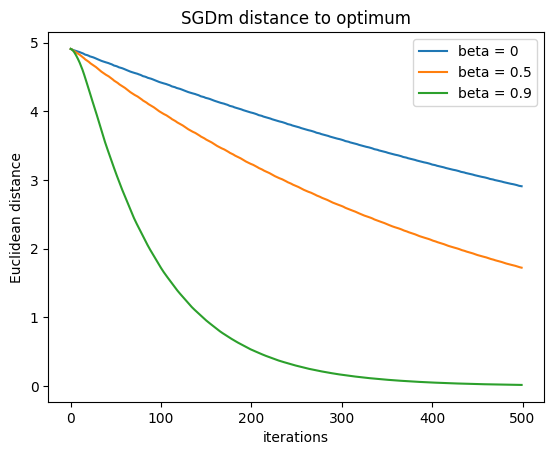

In [40]:
plt.plot(fit_sgdm(X, y, t_true, momentum = 0.0)[:500], label = 'beta = 0')
plt.plot(fit_sgdm(X, y, t_true, momentum = 0.5)[:500], label = 'beta = 0.5')
plt.plot(fit_sgdm(X, y, t_true, momentum = 0.9)[:500], label = 'beta = 0.9')
plt.legend()
plt.title('SGDm distance to optimum')
plt.xlabel('iterations')
plt.ylabel('Euclidean distance');
plt.show()

***Примечание.*** В коде выше вес прошлых градиентов $\beta$ обозначен как momentum, хотя инерцией или трендом, как мы сказали, называется компонент $v^{k-1}.$ Такое название переменной выбрано для того, чтобы сохранить единообразие с основными библиотеками для обучения нейросетей, например, с
Keras.

### Сглаживание без смещения

Прогнозирование тренда (информации о предыдущих шагах в случае SGDm) с использованием экспоненциально взвешенного скользящего среднего имеет один недостаток. Рассмотрим следующий временной ряд.

In [41]:
# 30 наблюдений
obs = np.array([33, 24, 31, 37, 36, 28, 31, 29, 35, 37, 38, 39, 36, 33, 34, 32, 35, 35, 32, 34, 36, 37, 33, 34, 30, 26, 30, 32, 34, 35])

Если положить $v_0 = 0$, то в соответствии с формулой экспоненциального сглаживания в первые несколько шагов значительный вес будет отдан именно нулевому значению. При этом значения первого и последующих наблюдений могут быть далеки от нуля, и скользящее среднее этого не учтет.

$$ \begin{array}{ll} v_0 & = 0 \\ v_1 & = 0{,}9 \cdot 0 + (1-0{,}9) \cdot 33 = 3{,}3 \\
v_2 & = 0{,}9 \cdot 3{,}3 + (1-0{,}9) \cdot 24 = 5{,}37 \end{array} $$

Возникает заметное **смещение** (bias). Для того чтобы справиться с этим, мы могли бы положить $v_0 = \theta_1.$ Однако это решает проблему лишь частично. Если, например, второе и последующие наблюдения $\theta_2, \theta_3, \ldots $
отличаются от первого, то опять же скользящее среднее будет в большей степени зависеть именно от $\theta_1.$

$$ \begin{array}{ll} v_0 & = 33 \\ v_1 & = 0{,}9 \cdot 33 + (1-0{,}9) \cdot 33 = 33 \\
v_2 & = 0{,}9 \cdot 33 + (1-0{,}9) \cdot 24 = 32{,}1 \end{array} $$

Более удачным представляется деление скользящего среднего на $1-\beta^t.$

$$ v_t = \frac{ \beta v_{t-1} + (1-\beta) \theta_t }{1-\beta^t} $$

В этом случае, так как $1-\beta^t$ меньше единицы, мы увеличиваем скользящее среднее. Одновременно, с ростом $t$ значение $1-\beta^t$ стремится к одному, и его эффект на $v_t$ становится меньше. Ровно то, что нам нужно.

Вычислим первые несколько значений.

$$ \begin{array}{ll} v_0 & = 0 \\ v_1 & = \frac{ 0{,}9 \cdot 0 + (1-0{,}9) \cdot 33 }{ 1-
0{,}9^1 } = {\color{Orange} 33 } \\ v_2 & = \frac{ 0{,}9 \cdot {\color{Orange} 3{,}3 }
+ (1-0{,}9) \cdot 24 }{ 1-0{,}9^2 } \approx 28{,}26 \end{array} $$

Обратим внимание на важный нюанс. На очередном шаге в формулу скользящего среднего $v_t$ мы подставляем предыдущее $v_{t-1}$ значение экспоненциального сглаживания *без учета корректировки* $1-\beta^t$ (сравните значения выделенные цветом).

Остальные расчеты проведем на Питоне.

In [42]:
beta = 0.9

# создадим два списка для обычного и несмещенного EWMA
# начальное значение v0 = 0
exp_smoothing = [0]
exp_smoothing_unbiased = [0]

# индекс i (в формуле обозначается t) идет от 1 до 30
for i in range(1, len(obs) + 1):
  # индекс сглаживания exp_smoothing[i - 1] и наблюдений obs[i - 1]
  # от 0 до 29, чтобы рассчитать EWMA для наблюдений от 1 до 30
  v = beta * exp_smoothing[i - 1] + (1 - beta) * obs[i - 1]

  # добавим очередное значение EWMA в списки
  exp_smoothing.append(v)
  exp_smoothing_unbiased.append(v / (1 - beta ** i))

И снова обратите внимание, хотя мы добавляем в список `exp_smoothing_unbiased` значение с учетом `(1 - beta ** i)`, значение переменной переходит на следующий шаг без корректировки.

Создадим датафрейм для наблюдений и значений обычного и несмещенного экспоненциально взвешенного скользящего среднего.

In [45]:
smoothing = pd.DataFrame({'obs':np.insert(obs, 0, 0),
                          'biased_EWMA':exp_smoothing,
                          'unbiased_EWMA':exp_smoothing_unbiased}).round(2)
smoothing.iloc[0,0] = np.nan

In [46]:
smoothing.head()

,obs,biased_EWMA,unbiased_EWMA
0,NaN,0.00,0.00
1,33.0,3.30,33.00
2,24.0,5.37,28.26
3,31.0,7.93,29.27
4,37.0,10.84,31.52


In [47]:
smoothing.tail()

,obs,biased_EWMA,unbiased_EWMA
26,26.0,30.84,32.97
27,30.0,30.76,32.66
28,32.0,30.88,32.59
29,34.0,31.19,32.74
30,35.0,31.57,32.97


Несложно заметить, что эффект корректировки на первых значениях выражен сильнее, чем на последних. Посмотрим на эти данные на графике.

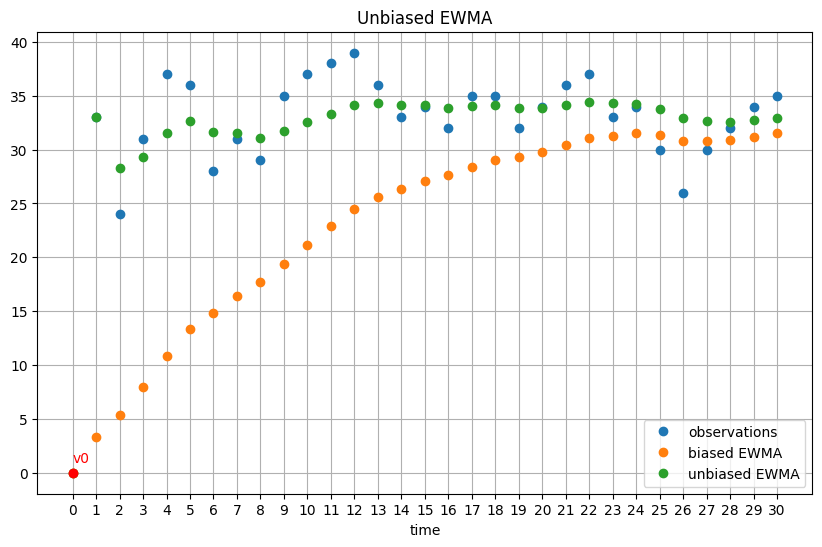

In [48]:
time = np.arange(1, 31)

plt.figure(figsize=(10,6))
plt.plot(time, obs, 'o', label = 'observations')
plt.plot(exp_smoothing, 'o', label = 'biased EWMA')
plt.plot(exp_smoothing_unbiased, 'o', label = 'unbiased EWMA')
plt.plot(0, 0, 'ro')
plt.annotate('v0', (0, 1), color = 'r')
plt.legend()
plt.title('Unbiased EWMA')
plt.xlabel('time')
plt.xticks(np.arange(31))
plt.grid()
plt.show()

Эту же идею можно использовать и в градиентном спуске.

$$ v^{k} = \beta v^{k-1} + (1-\beta) \nabla f_{i} (\theta^{k}) $$

$$ \hat{v}^k = \frac{v^k}{1-\beta^k} $$

$$ \theta^{k+1} := \theta^{k}-\eta \hat{v}^k, $$

In [49]:
def fit_sgdm_unbiased(x, y,
                      t_opt,
                      batch_size = 32,
                      epochs = 3125,
                      lr = 0.001,
                      momentum = 0.9):

  x, y = x.copy(), y.copy()

  thetas = np.zeros(x.shape[1])
  v = np.zeros(x.shape[1])
  k = 1

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      v = momentum * v + (1 - momentum) * gradient(x_b, y_b, thetas, n)
      v_hat = v / (1 - momentum ** k)
      thetas -= lr * v_hat
      k += 1

  return dist_to_opt

Вновь обратим внимание, на следующий шаг переходит значение $v^k$ без корректировки.

### Dampening

Еще раз рассмотрим уже знакомую нотацию SGDm.

$$ v^{k} = \beta v^{k-1} + (1-\beta) \nabla f_{i} (\theta^{k}) $$

$$ \theta^{k+1} := \theta^{k}-\eta v^{k} $$

Если заменить коэффициент $(1-\beta)$ на $(1-\tau)$, где $\tau$ — коэффициент затухания (dampening), мы смогли бы отдельно контролировать значимость градиента.

$$ v^{k} = \beta v^{k-1} + (1-\tau) \nabla f_{i} (\theta^{k}) $$

$$ \theta^{k+1} := \theta^{k}-\eta v^{k} $$

В случае $\tau = \beta$ речь очевидно идет об обычном SGDm.

In [50]:
 def fit_sgdm_dampening(x, y,
                       t_opt,
                       batch_size = 32,
                       epochs = 3125,
                       lr = 0.001,
                       momentum = 0.9,
                       dampening = 0.1):

  x, y = x.copy(), y.copy()

  thetas = np.zeros(x.shape[1])
  v = np.zeros(x.shape[1])

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      v = momentum * v + (1 - dampening) * gradient(x_b, y_b, thetas, n)
      thetas -= lr * v

  return dist_to_opt

Подобный функционал реализован, в частности, в библиотеке PyTorch

### Nesterov Momentum

Представим, что информация о предыдущих шагах $v^k$ ведёт к неоптимальному изменению параметров $\theta$. Возвращаясь к аналогии с физическим миром, предположим, что место, куда ведёт инерция, для шага $k+1$ вскоре сменится подъемом, и шарик соответственно замедлится.

Если рассчитать изменение текущего градиента именно в точке, куда ведёт прошлый градиент, так называемый, lookahead, $\theta_{\text{ahead}}^k$, то такое потенциально неудачное перемещение можно скорректировать сильнее, чем мы бы это сделали в точке $\theta^k$, пользуясь обычным методом SGDm.

Этот метод, предложенный Ю.Е. Нестеровым, получил название **Nesterov Momentum** или Nesterov Accelerated Gradient (NAG).

![](https://drive.google.com/uc?export=view&id=1yEelhhOKa9z9McOXOqYCkc_qaWQo33Zd)

Таким образом, для обновления весов необходимо:
1. найти точку (значения весов в точке) $\theta_{\text{ahead}}^k$, на которую
указывает прошлый градиент $\beta v^{k-1};$
2. вычислить текущий градиент $-\eta \nabla f_{i} (\theta_{\text{ahead}}^{k})$ и
найти новый шаг, т.е. сумму векторов $v^k = \beta v^{k-1}+(-\eta \nabla f_{i}
(\theta_{\text{ahead}}^{k}));$
3. обновить веса c $\theta^k$ до $\theta^{k+1}$ с помощью $v^k.$

Более формально,

$$ \theta^k_{\text{ahead}} = \theta^k + \beta v^{k-1} $$

$$ v^k = \beta v^{k-1}+(-\eta \nabla f_{i} (\theta_{\text{ahead}}^{k})) $$

$$ \theta^{k+1} := \theta^k + v^k $$

Напишем код на Питоне.

In [51]:
def fit_nesterov(x, y,
                 t_opt,
                 batch_size = 32,
                 epochs = 3125,
                 lr = 0.001,
                 momentum = 0.9):

  x, y = x.copy(), y.copy()

  thetas = np.zeros(x.shape[1])
  v = np.zeros(x.shape[1])

  dist_to_opt = []

  v = np.zeros(x.shape[1])

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      thetas_ahead = thetas + momentum * v
      v = momentum * v - lr * gradient(x_b, y_b, thetas_ahead, n)
      thetas += v

  return dist_to_opt

### Промежуточный итог
В первой части занятия мы посмотрели, каким образом можно улучшить алгоритм градиентного спуска, (1) варьируя количество наблюдений, на основе которых рассчитывается градиент, а также (2) используя информацию о предыдущих шагах.

Список литературы

* A Stochastic Approximation Method, Robbins and Monro, 1951
* О некоторых способах ускорения сходимости итерационных методов (https://www.mathnet.ru/php/archive.phtml?wshow=paper&jrnid=zvmmf&paperid=7713&option_lang=rus), Б.Т. Поляк, 1964
* Beneath the valley of the noncommutative arithmetic-geometric mean inequality: conjectures, case-studies, and consequences (https://arxiv.org/pdf/1202.4184), B. Recht and C. Ré.
* Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour (https://arxiv.org/pdf/1706.02677), Goyal et al., 2018
* Accelerating Stochastic Gradient Descent using Predictive Variance Reducti (https://stat.arizona.edu/sites/default/files/2024-02/Journal%20Paper%20021224.pdf), Johnson & Zhang, 2013


# Стохастический градиентный спуск. Часть 2
В первой части мы познакомились с алгоритмом SGD и использованием инерции. Во второй части занятия мы начнем изучать способы изменения размера шага в алгоритме стохастического градиентного спуска. Кроме того, мы рассмотрим еще один градиентный метод — метод наискорейшего спуска.

При этом прежде всего рассмотрим теоретическое обоснование того, зачем (в большинстве случаев) рекомендуется уменьшать размер шага в процессе обучения алгоритма SGD.


## SGD и размер шага
В процессе full batch градиентного спуска значение градиента $ \nabla f (\theta) $ всегда указывает «правильное» направление обновления весов в сторону $\theta^*.$
Это обусловлено тем, что каждый раз мы рассчитываем градиент на *всем* наборе данных, и у нас *одна* функция потерь $f (\theta).$

При этом в стохастическом градиентном спуске, поскольку мы на каждом шаге рассчитываем градиент $ \nabla f_{i} (\theta)$ на разных данных, речь идет о нескольких функциях потерь $f_{i} (\theta),$ и градиент не всегда указывает в сторону $\theta^*.$

### Простой пример

Рассмотрим задачу оптимизации с единственным параметром $\theta$ и набором данных, состоящим из трех наблюдений $(x_i, y_i).$

In [52]:
# зададим пространство параметра
theta = np.linspace(-30, 30, 100)

# и данные
X = np.array([0.8, 0.7, 0.6])
y = np.array([-6, 3, 7])

Возьмем квадратичную функцию потерь. Для трех наблюдений она будет иметь вид

$$ f(\theta) = \frac{1}{3} \sum^3_{i=1} (\theta x_i-y_i)^2 $$

При этом отдельные функции потерь, рассчитываемые на основе каждого из наблюдений, будут заданы через

$$ f_1(\theta) = (\theta x_1-y_1)^2 $$

$$ f_2(\theta) = (\theta x_2-y_2)^2 $$

$$ f_3(\theta) = (\theta x_3-y_3)^2 $$

In [53]:
# объявим функцию потерь для всего набора данных и
def f(theta, x, y):
  return np.sum((x * theta - y) ** 2) / len(x)

# функцию для каждой пары (x_i, y_i)
def f_i(theta, x_i, y_i):
  return (x_i * theta - y_i) ** 2

Найдем градиенты общей функции потерь и функций отдельных наблюдений.

$$ \nabla f(\theta) = 2 \sum_i x_i (x_i \theta-y_i) $$

$$ \nabla f_i(\theta) = 2x_i (x_i \theta-y_i) $$

In [54]:
# объявим градиент f_i в точке theta
def grad_i(theta, x_i, y_i):
  return (2 * x_i) * (x_i * theta - y_i)

Тогда минимумы этих функций можно найти через $ \nabla f(\theta) = 0$ и $ \nabla f_i(\theta) = 0.$ Получаем.

$$ \theta^* = \frac{ \sum_i x_i y_i }{ \sum_i x_i^2 }, \quad \theta^*_i = \frac{y_i}{x_i}
$$

Найдем $\theta^*$ общей функции потерь и значение $f(\theta^*).$

In [56]:
# найдем минимум общей функции потерь и
# значение функции в этой точке
theta_opt = (np.dot(X, y) / np.dot(X, X)).round(2)
theta_opt, f(theta_opt, X, y).round(2)

(np.float64(1.01), np.float64(30.83))

In [57]:
# минимум и значение функции в минимуме можно найти и так
from scipy.optimize import minimize
min_ = minimize(f, x0 = 5, args = (X, y))
min_.x.round(2), min_.fun.round(2)

(array([1.01]), np.float64(30.83))

Также найдем значение каждой из трех $ \theta_i^*$ и выведем минимальное $ \min
\theta_i^* $ и максимальное $ \max \theta_i^* $ значения этого перечня (для чего это
нужно, станет понятно чуть позже).

In [58]:
# найдем минимальные значения каждой из f_i
min_i_list = []
for x_i, y_i in zip(X, y):
  min_i_list.append((y_i/x_i).round(1))

# найдем минимальное и максимальное значения этих оптимумов min_i_opt, max_i_opt = min(min_i_list), max(min_i_list)
min_i_opt, max_i_opt

(np.float64(-7.5), np.float64(11.7))

Построим общую функцию потерь $f(\theta),$ функции $f_i (\theta),$ а также покажем общий минимум $\theta^*$ и минимальное и максимальное значения оптимумов $f_i (\theta).$

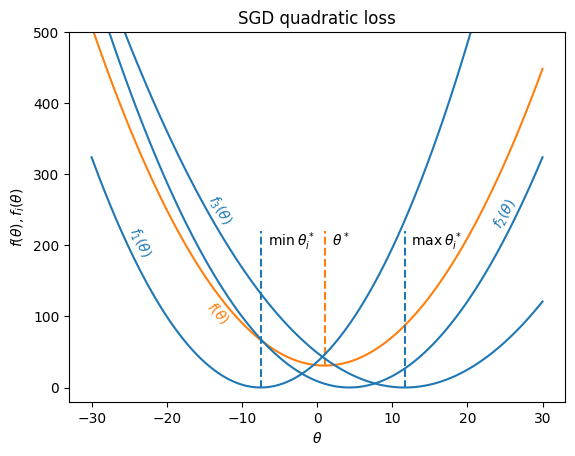

In [59]:
# построим общую функцию потерь
plt.plot(theta, [f(theta_i, X, y) for theta_i in theta], c = 'C1')
# сделаем подпись и
plt.annotate(r'$f (\theta)$', (-15, 90), rotation = -48, c = 'C1')
# покажем ее оптимум
plt.vlines(x = theta_opt, ymin = f(theta_opt, X, y), ymax = 220,
           colors = 'C1', linestyles = 'dashed')
plt.annotate(r'$\theta^*$', (2, 200))

# построим функции потерь отдельных наблюдений
for i, (x_i, y_i) in enumerate(zip(X, y), 1):
  plt.plot(theta, f_i(theta, x_i, y_i), c = 'C0')

# сделаем подпись и покажем минимум первой функции
# (он совпадает со значением минимального оптимума)
plt.annotate(r'$f_1 (\theta)$', (-25.5, 185), rotation = -65, c = 'C0')
plt.vlines(x = min_i_opt, ymin = 0, ymax = 220, colors = 'C0', linestyles = 'dashed')
plt.annotate(r'$\min \: \theta_i^*$', (-6.5, 200))

# сделаем подпись ко второй функции
plt.annotate(r'$f_2 (\theta)$', (23, 225), rotation = 60, c = 'C0')

# сделаем подпись и покажем минимум третьей функции
# (он совпадает со значением максимального оптимума)
plt.annotate(r'$f_3 (\theta)$', (-15, 230), rotation = -60, c = 'C0')
plt.vlines(x = max_i_opt, ymin = 0, ymax = 220, colors = 'C0', linestyles = 'dashed')
plt.annotate(r'$\max \: \theta_i^*$', (12.5, 200))

plt.title('SGD quadratic loss')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$f(\theta), f_i(\theta)$')
plt.ylim(-20, 500)
plt.show()

На графике хорошо видно, что при стохастическом градиентном спуске мы рассчитываем градиенты относительно трех функций потерь отдельных наблюдений. Покажем несколько возможных градиентов на графике.

## Касательные к функции потерь
Возьмем три значения параметра $\theta’$ и построим касательные (градиенты) к
функциям потерь $f_i (\theta)$ в этих точках. Пусть
точки со значениями аргумента $ \theta’_1 = -20 $ и $\theta’_2 = -1 $ лежат на
функции $f_1 (\theta);$ а
точка $ \theta’_3 = 25 $ лежит на функции $f_2(\theta).$
Найдем значения соответствующих функций $f_i (\theta’)$ в этих точках.

In [60]:
# зададим координаты точек касания (theta_prime_i, f_prime_i)

# так как первые две точки лежат на функции f_1,
# мы используем данные первого наблюдения (X[0], y[0])
theta_prime_1 = -20
f_prime_1 = f_i(theta_prime_1, X[0], y[0])

theta_prime_2 = -1
f_prime_2 = f_i(theta_prime_2, X[0], y[0])

# так как третья точка лежит на функции f_2,
# мы используем данные второго наблюдения (X[1], y[1])
theta_prime_3 = 25
f_prime_3 = f_i(theta_prime_3, X[1], y[1])

Зададим уравнение касательной.

$$ \text{tangent line} = \underbrace{ \nabla f_{i} (\theta’) }_{\text{slope}} (\theta-
\theta’) + f_i(\theta’) $$

In [61]:
# уравнение касательной
# f_prime - значение функции f_i в точке theta_prime
def line(theta_prime, f_prime, theta, x_i, y_i):
  return (grad_i(theta_prime, x_i, y_i) * (theta - theta_prime)) + f_prime

Вновь построим аналогичный график, только на этот раз покажем касательные в точках $\theta’.$

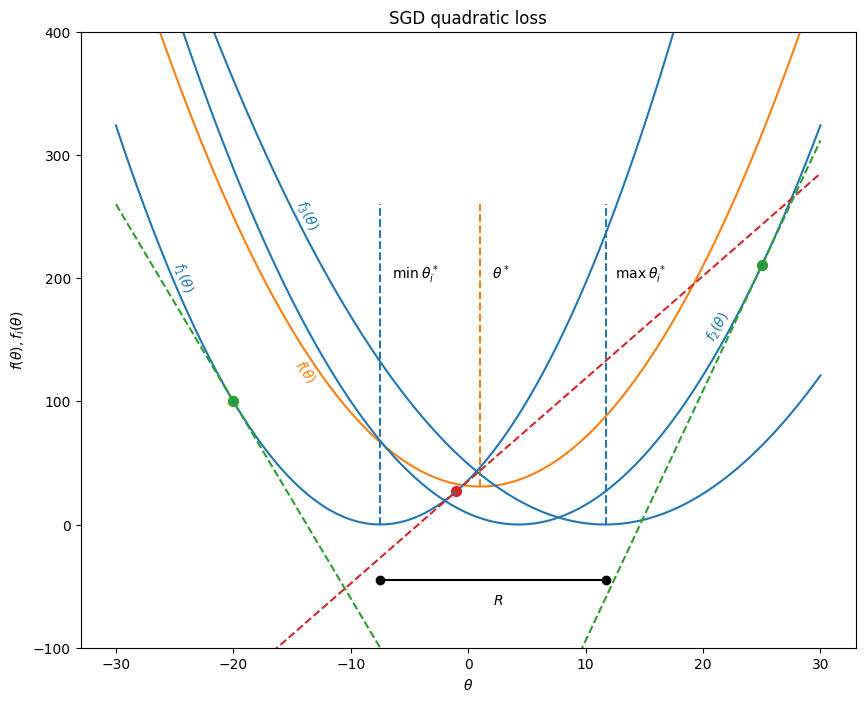

In [62]:
plt.figure(figsize=(10,8))

# построим общую функцию потерь
plt.plot(theta, [f(theta_i, X, y) for theta_i in theta], c = 'C1')
plt.annotate(r'$f (\theta)$', (-15, 115), rotation = -55, c = 'C1')

# покажем истинный оптимум
plt.vlines(x = theta_opt, ymin = f(theta_opt, X, y), ymax = 260,
           colors = 'C1', linestyles = 'dashed')
plt.annotate(r'$\theta^*$', (2, 200))

# построим функции потерь отдельных наблюдений f_i
for i, (x_i, y_i) in enumerate(zip(X, y), 1):
  plt.plot(theta, f_i(theta, x_i, y_i), c = 'C0')

# покажем минимальное и
plt.vlines(x = min_i_opt, ymin = 0, ymax = 260, colors = 'C0', linestyles = 'dashed')
plt.annotate(r'$\min \: \theta_i^*$', (-6.5, 200))
# максимальное значения оптимумов функций f_i
plt.vlines(x = max_i_opt, ymin = 0, ymax = 260, colors = 'C0', linestyles = 'dashed')
plt.annotate(r'$\max \: \theta_i^*$', (12.5, 200))

# сделаем подписи к f_i
plt.annotate(r'$f_1 (\theta)$', (-25.5, 190), rotation = -70, c = 'C0')
plt.annotate(r'$f_2 (\theta)$', (20, 150), rotation = 60, c = 'C0')
plt.annotate(r'$f_3 (\theta)$', (-15, 240), rotation = -65, c = 'C0')

# построим касательные
plt.plot(theta, line(theta_prime_1, f_prime_1, theta, X[0], y[0]), '--', color = 'C2')
plt.scatter(theta_prime_1, f_prime_1, color = 'C2', s = 50)

plt.plot(theta, line(theta_prime_2, f_prime_2, theta, X[0], y[0]), '--', color = 'C3')
plt.scatter(theta_prime_2, f_prime_2, color = 'C3', s = 50)

plt.plot(theta, line(theta_prime_3, f_prime_3, theta, X[1], y[1]), '--', color = 'C2')
plt.scatter(theta_prime_3, f_prime_3, color = 'C2', s = 50)

# покажем интервал между минимальным и максимальным оптимумом f_i
plt.plot([min_i_opt, max_i_opt], [-45, -45], '-o', color='k')
plt.annotate(r'$R$', ((min_i_opt + max_i_opt)/2, -65))

plt.title('SGD quadratic loss')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$f(\theta), f_i(\theta)$')
plt.ylim(-100, 400)
plt.show()

Как мы сказали ранее, стохастический градиентный спуск является несмещенной оценкой full batch градиента.

$$ \mathbb{E} [\nabla f_{i} (\theta)] = \nabla f(\theta) $$

Другими словами, в среднем градиенты отдельных функций должны привести нас к истинному минимуму $\theta^*.$ При этом, как видно на рисунке выше, в каждом отдельном случае градиенты $ \nabla f_{i} (\theta)$ могут указывать:
* как в сторону $\theta^*$ и, таким образом, снижать общую ошибку (рассчитываем «зеленые» градиенты, однако ошибку измеряем по «оранжевой» функции);
* так и указывать в обратную от $\theta^*$ сторону и соответственно эту ошибку повышать (например, «красный» градиент).

### Region of confusion
Более того, удаленные от $\theta^*$ «зеленые» градиенты всегда указывают «верное» направление, но по мере приближения к истинному минимуму, могут ошибаться.

Можно также сказать, что «зеленые» градиенты $ \nabla f_i(\theta) $ имеют **тот же знак**, что и градиенты общей функции потерь $\nabla f(\theta), $ а «красные» $ \nabla f_i(\theta) $ могут совпадать с ними по знаку или не совпадать.

Интервал, в котором направление градиентов может изменяться, называют **region of confusion**, $R.$ У него есть две особенности:
* границы этого интервала определены минимальным и максимальным
значением оптимумов функций отдельных наблюдений $f_i(\theta)$ (именно для этого мы находили их выше);
* истинный минимум $ \theta^* $ всегда находится внутри $R$ (ведь за его пределами «зеленые» градиенты всегда совпадают по знаку с общим градиентом).

Более формально,

$$ \theta^* \in \biggl[ \min_i \theta_i^*, \; \max_i \theta_i^* \biggr] =: R $$

Это приводит к появлению двух фаз стохастического градиентного спуска:
* уровень ошибки быстро снижается до определенного уровня («зеленые градиенты»); затем
* начинаются хаотичные незатухающие колебания («красные градиенты»).

Приведем две иллюстрации. Вначале сравним расстояние до оптимума последних 500 итераций full batch и SGD алгоритмов, которые мы создали в первой части.

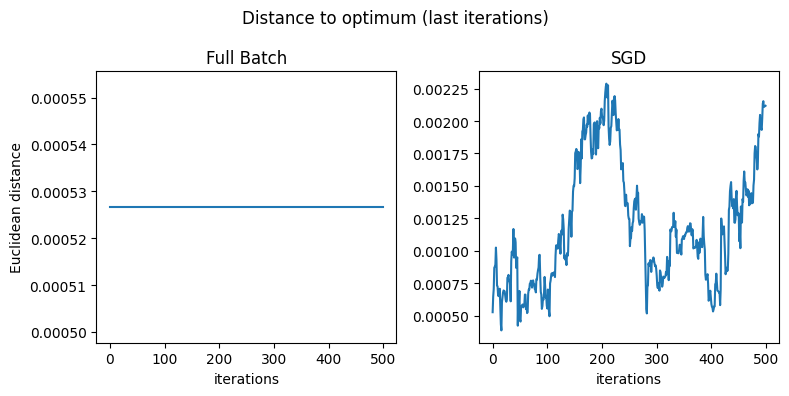

In [63]:
fig = plt.figure(figsize = (8,4))
fig.suptitle('Distance to optimum (last iterations)')
ax1 = fig.add_subplot(121, title = 'Full Batch')
ax1.plot(dist_fb[-500:])
ax1.set_xlabel('iterations')
ax1.set_ylabel('Euclidean distance')
ax2 = fig.add_subplot(122, title = 'SGD')
ax2.plot(dist_sgd[-500:])
ax2.set_xlabel('iterations')
plt.tight_layout()
plt.show()

Теперь сравним процесс обучения алгоритма с функцией двух параметров $f(\theta_1, \theta_2)$ для размера шага $\eta = 0{,}02$ и $\eta = 0{,}06.$
![](https://drive.google.com/uc?export=view&id=183moDHGCAD9Y3Q2v1M_Ibs3Trhow2K2n)

![](https://drive.google.com/uc?export=view&id=1h5nTKFXqqwLc8qH7-Ls8yn8nnR_PC7UL)




В этом примере мы также можем наблюдать две фазы SGD, однако речь идет уже не об интервале, а об окружности, диаметр которой описывает хаотические колебания второй фазы.

Заметим, что хотя SGD сохраняет незатухающие колебания, он подходит для решения практических задач, где нет необходимости достичь оптимума на обучающей выборке, но есть задача быстро снизить ошибку и показать хорошие результаты на тестовых данных.

### Дисперсия градиента
Однако, в случае когда колебания слишком велики, алгоритм SGD может быть неэффективен. Опишем колебания с помощью **дисперсии** стохастического градиента относительно full-batch градиента

$$ Var(\text{SGD}) = \frac{1}{n} \sum^n_{i=1} || \nabla f_{i} (\theta)-\nabla f (\theta)
||^2 $$

Можно сказать, что
* за пределами region of confusion дисперсия равна нулю; а
* внутри этого интервала дисперсия больше нуля и увеличивается по мере приближения к $\theta^*.$

При этом несложно заметить, что ширина интервала (диаметр окружности) пропорциональна размеру шага

$$ R \propto \eta, $$

а дисперсия внутри $R$ пропорциональна квадрату размера шага

$$ Var(\text{SGD}) \propto \eta^2 $$

Как следствие, если мы хотим, чтобы стохастический градиентный спуск сходился к $\theta^*,$ нам необходимо постепенно уменьшать $\eta.$
***Примечание***. С точки зрения нотации изменяющийся размер шага мы будем обозначать как $\eta_k.$ Другими словами, формула SGD будет иметь вид

$$ \theta^{k+1} := \theta^{k}-\eta_k \cdot \nabla f_{i} (\theta^{k}), \quad k = 1, 2, 3,
\ldots $$

### Критерии сходимости
Формально сходимость стохастического градиентного спуска обеспечивается таким выбором последовательности $\eta,$ для которой выполняются следующие условия

$$ \sum_{k=1}^\infty (\eta_k) = \infty \quad \text{и} \quad \sum_{k=1}^\infty (\eta_k)^2
< \infty $$

Первое условие (1) описывает изменение размера шага по мере увеличения $k.$ Нам важно, чтобы этот ряд расходился, поскольку так мы гарантированно «дойдем» до точки минимума. Согласно второму условию (2) дисперсия градиента должна стремиться к нулю.

Распространенным решением является последовательность $ \eta_k = \frac{1}{k} $. И действительно при

$$ \lim_{k \to \infty} \frac{1}{k} = 0 $$

выполняется

$$ \sum_{k=1}^\infty \left( \frac{1}{k} \right) = \infty, \qquad \quad \sum_{k=1}^\infty
\left( \frac{1}{k} \right)^2 = \frac{\pi^2}{6} $$


## Расписания

На практике речь идет о применении различных расписаний (schedules), которые позволяют постепенно снижать размер шага (learning rate decay). Рассмотрим некоторые виды таких расписаний.
### Inverse time decay
Размера шага можно уменьшать путем умножения на коэффициент, обратно пропорциональный эпохе.

$$ \eta_k = \frac{ \eta_{0} }{ 1 + r \cdot \text{epoch} }, $$

где $\eta_0$ — начальный размер шага, а $r$ — коэффициент затухания (decay rate).

In [64]:
def inv_time_decay(epoch, lr = 0.1, decay = 0.05):
  return lr / (1 + decay * epoch)

Заметим, что коэффициент затухания часто задают как отношение размера шага к количеству эпох.

$$ r = \frac{ \eta_0 }{ \text{epochs} } $$

Например,

In [65]:
lr, epochs = 0.1, 50

decay = lr / epochs
decay

0.002

### Polynomial decay

Кроме этого, можно использовать полиномиальную функцию

$$ \eta_k = \eta_0 \cdot \left( 1-\frac{ \text{epoch} }{ \text{epochs} } \right)^{p}, $$

где $p$ указывает на степень полинома:
* ем меньше степень, тем медленнее происходит угасание размера шага;
* одновременно при $\eta = 1$ очевидным образом происходит линейное уменьшение шага.

Поскольку, следуя такому расписанию, на последнем шаге $\eta$ будет равна нулю (а нам бы этого не хотелось), формулу модифицируют следующим образом

$$ \eta_k = (\eta_{\text{start}}-\eta_{\text{end}}) \cdot \left( 1-\frac{ \text{epoch} }{
\text{epochs} } \right)^{p} + \eta_{\text{end}}, $$

где $\eta_{\text{start}}$ и $\eta_{\text{end}}$ представляют собой гиперпараметры, определяющие начальный и конечный размер шага, и $p$ — степень полинома.

In [66]:
# по умолчанию eta линейно уменьшается с 0,1 до 0,01 за 100 эпох
def polynomial_decay(epoch, epochs = 100, start_lr = 0.1, end_lr = 0.01, power = 1):
  return ((start_lr - end_lr) * (1 - epoch / epochs) ** power) + end_lr

### Step-based decay
Помимо этого, размер шага можно уменьшать каждые несколько эпох
$(\text{epochs drop})$ в определенное количество раз $(\text{drop rate}).$

$$ \eta = \eta_0 \cdot \text{drop rate}^{\lfloor \frac{ \text{epoch} }{ \text{epochs drop}
} \rfloor }, $$

где $\lfloor \; \rfloor $ — функция пола для получения наибольшего целого числа, меньшего или равного заданному. Посмотрим, как это работает с помощью Питона. Пропишем функцию.

In [67]:
# по умолчанию eta уменьшается в два раза на каждой пятой эпохе
def step_decay(epoch, lr = 0.1, drop_rate = 0.5, epochs_drop = 5):
  return lr * (drop_rate ** np.floor(epoch / epochs_drop))

Теперь выведем размер шага для первых десяти эпох с параметрами по умолчанию (левая колонка ниже). Кроме того, выведем (правая колонка):
* отношение до функции пола $\frac{ \text{epoch} }{ \text{epochs drop} };$
* результат после функции пола, то есть степень, в которую будет возводиться $\text{drop rate};$ а также
* коэффициент угасания $\text{drop rate}$ на каждой эпохе.

In [68]:
drop_rate, epochs_drop = 0.5, 5

for epoch in range(15):
  print(step_decay(epoch), '\t', epoch / epochs_drop, np.floor(epoch / epochs_drop), \
        drop_rate ** np.floor(epoch / epochs_drop))

0.1 	 0.0 0.0 1.0
0.1 	 0.2 0.0 1.0
0.1 	 0.4 0.0 1.0
0.1 	 0.6 0.0 1.0
0.1 	 0.8 0.0 1.0
0.05 	 1.0 1.0 0.5
0.05 	 1.2 1.0 0.5
0.05 	 1.4 1.0 0.5
0.05 	 1.6 1.0 0.5
0.05 	 1.8 1.0 0.5
0.025 	 2.0 2.0 0.25
0.025 	 2.2 2.0 0.25
0.025 	 2.4 2.0 0.25
0.025 	 2.6 2.0 0.25
0.025 	 2.8 2.0 0.25


Например, на эпохах с 10 по 14 (если считать с нуля) $\eta$ уменьшается в 4 раза и составляет $ 0{,}1 \cdot 0{,}25 = 0{,}025.$

### Exponential decay
Размер шага можно также уменьшать по экспоненте

$$ \eta_k = \eta_0 \cdot e^{-r \cdot {\text{epoch}}} $$

In [69]:
def exp_decay(epoch, lr = 0.1, decay = 0.05):
  return lr * np.exp(-decay * epoch)

### Сравнение расписаний

Сравним расписания на графике.

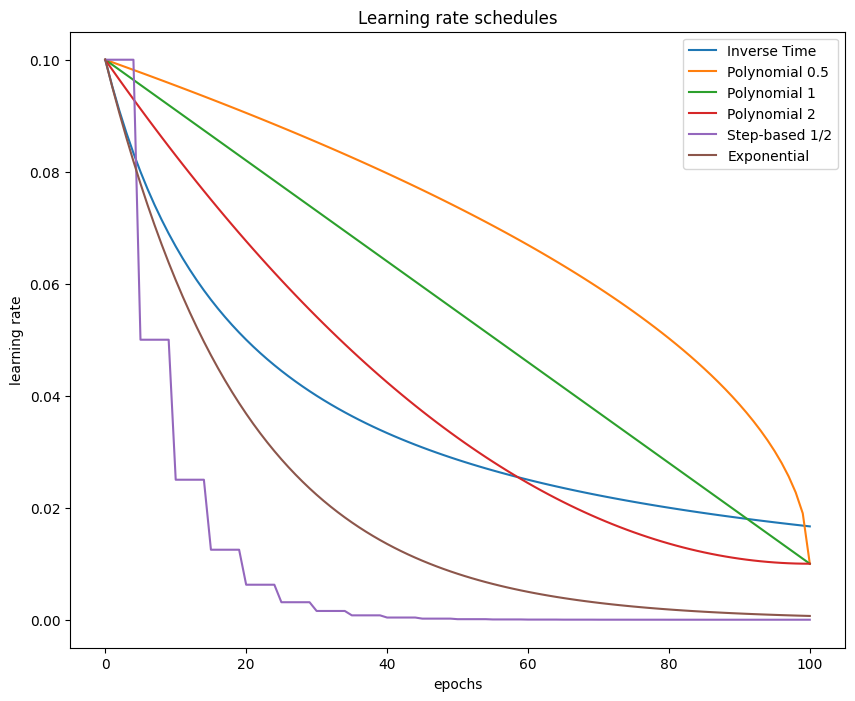

In [70]:
epoch = np.arange(101)

plt.figure(figsize=(10,8))

plt.plot(epoch, inv_time_decay(epoch), label = 'Inverse Time')
plt.plot(epoch, polynomial_decay(epoch, power = 0.5), label = 'Polynomial 0.5')
plt.plot(epoch, polynomial_decay(epoch, power = 1), label = 'Polynomial 1')
plt.plot(epoch, polynomial_decay(epoch, power = 2), label = 'Polynomial 2')
plt.plot(epoch, step_decay(epoch), label = 'Step-based 1/2')
plt.plot(epoch, exp_decay(epoch), label = 'Exponential')
plt.legend()

plt.title('Learning rate schedules')
plt.xlabel('epochs')
plt.ylabel('learning rate')
plt.show()

Опять же обратим внимание, что в полиномиальной функции:
* наиболее быстро снижается полином с наиболее высокой степенью; кроме этого
* мы дошли ровно до конечной точки расписания с $ \eta_{\text{end}} = 0{,}01.$

### SGD с расписанием
Модифицируем алгоритм стохастического градиентного спуска.

In [71]:
def fit_sgd_schedule(x, y, t_opt, batch_size,
                     epochs = 50, lr = 0.1,
                     schedule = None,
                     decay = None,
                     epochs_drop = None,
                     end_lr = 0.01,
                     power = 1):

  x, y = x.copy(), y.copy()
  thetas = np.zeros(x.shape[1])

  # зададим eta_0
  initial_lr = lr

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      grad = gradient(x_b, y_b, thetas, n)
      thetas = thetas - lr * grad

    if schedule == 'inv_time_decay':
      lr = initial_lr / (1 + decay * epoch)

    elif schedule == 'polynomial_decay':
      lr = ((initial_lr - end_lr) * (1 - epoch / epochs) ** power) + end_lr

    elif schedule == 'step_decay':
      lr = initial_lr * decay ** np.floor(epoch / epochs_drop)

    elif schedule == 'exp_decay':
      lr = initial_lr * np.exp(-decay * epoch)

  return dist_to_opt

Применим алгоритм к синтетическим данным.

In [72]:
t_true = np.array([3.2, 2, -2.7, 1.6])
X, y = synth_reg_data(t_true)

In [73]:
dist_schedule = fit_sgd_schedule(X, y, t_true, batch_size = 1,
                                 epochs = 100, lr = 0.1,
                                 schedule = 'exp_decay',
                                 decay = 0.05)

Сравним обычный SGD (или как еще говорят vanilla SGD) с алгоритмом, который постепенно уменьшает размер шага по экспоненте.

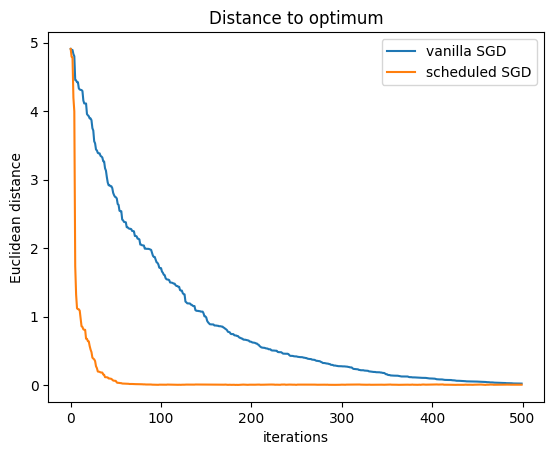

In [74]:
plt.plot(dist_sgd[:500], label = 'vanilla SGD')
plt.plot(dist_schedule[:500], label = 'scheduled SGD')
plt.legend()

plt.title('Distance to optimum')
plt.xlabel('iterations')
plt.ylabel('Euclidean distance')
plt.show()

Разница на одних и тех же данных весьма существенная. Сделаем два замечания:
* во-первых, обратим внимание, что мы увеличили первоначальный размер шага, это оправданно, так как $\eta$ будет довольно быстро снижаться;
* кроме того, заметим, что ничто не мешает объединять инерцию и уменьшение размера шага в одном алгоритме, выше мы не сделали этого ради упрощения кода.

Дополним изложение сравнением расстояния до оптимума на последних итерациях.

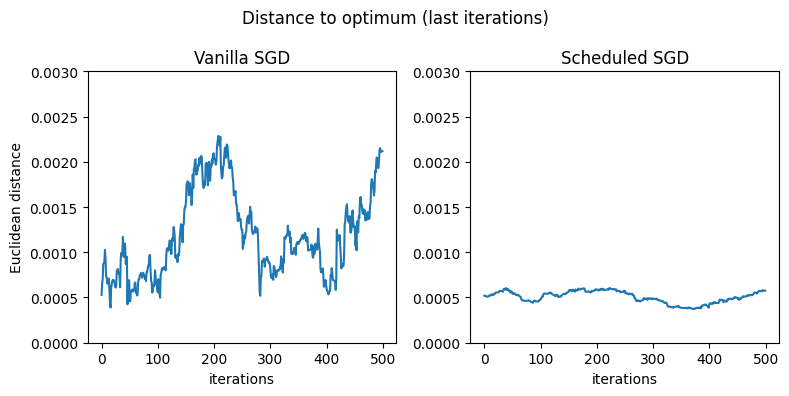

In [75]:
fig = plt.figure(figsize = (8,4))
fig.suptitle('Distance to optimum (last iterations)')
ax1 = fig.add_subplot(121, title = 'Vanilla SGD')
ax1.plot(dist_sgd[-500:])
ax1.set_xlabel('iterations')
ax1.set_ylabel('Euclidean distance')
ax1.set_ylim(0, 0.003)
ax2 = fig.add_subplot(122, title = 'Scheduled SGD')
ax2.plot(dist_schedule[-500:])
ax2.set_xlabel('iterations')
ax2.set_ylim(0, 0.003)
plt.tight_layout()
plt.show()

Мы видим, что на заключительных итерациях колебания стали существенно меньше.

### Warmup и warm restarts

Размер шага можно не только уменьшать, но и также
* линейно увеличивать в начале обучения, и тогда говорят о «разогреве»
коэффициента скорости обучения (learning rate linear warmup); или
* периодически «восстанавливать» до первоначального уровня после
определенного количества эпох, а затем снова начинать уменьшение (warm restarts).

Во втором случае restart называется «теплым» (warm), поскольку при восстановлении размера шага веса не «сбрасываются» до нулевого или случайного значения, как это бывает при начале обучения и соответственно «холодном» старте
(cold start).

Проиллюстрируем эти подходы.

#### Learing rate warmup
Приведем формулу линейного увеличения шага.

$$ \eta_k = (\eta_{\text{target}}-\eta_{\text{init}}) \cdot \frac{ \text{epoch} }{
\text{warmup epochs} }, $$

где $\eta_{\text{init}}$ и $\eta_{\text{target}}$ — размеры шага в начале и в конце фазы «разогрева».

In [76]:
def warmup(epoch, init_lr, target_lr, warmup_epochs):
  return (target_lr - init_lr) * (epoch / warmup_epochs)

Покажем изменение $\eta$ с warmup на обучении длинною 120 эпох.

In [77]:
# создадим расписание с warmup
lr_schedule = []

# warmup будет длиться 20 эпох, убывание - 100
warmup_epochs, epochs = 20, 100

for epoch in range(warmup_epochs):
  # вначале eta будет возрастать от 0 до 0,1 в течение 20 эпох
  lr_schedule.append(warmup(epoch, 0, 0.1,
                            warmup_epochs = warmup_epochs))

for epoch in range(epochs):
  # затем eta будет убывать по экспоненте
  # с уровня 0,1 со скоростью 0,05
  lr_schedule.append(exp_decay(epoch, 0.1, 0.05))

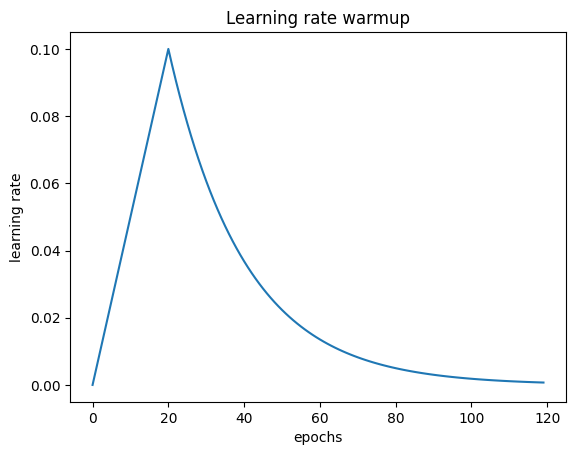

In [78]:
plt.plot(lr_schedule)
plt.title('Learning rate warmup')
plt.xlabel('epochs')
plt.ylabel('learning rate')
plt.show()

#### Warm restarts и cosine decay
Warm restarts можно обеспечить, если заставить $\eta$ следовать косинусоиде. В этом случае говорят о cosine decay. Авторы метода предлагают следующее правило изменения размера шага

$$ \eta_k = \eta_{\min} + \underbrace { \frac{1}{2} \biggl( \eta_{\max}-\eta_{\min}
\biggl) }_{\text{amplitude} } \cdot \underbrace { \left( 1 + \cos \left( \frac{ \text{epoch}
}{ \text{epochs} } \cdot \pi \right) \right) }_{\text{decay} }, $$

где $\eta_{\min}$ и $ \eta_{\max} $ задают минимальный и максимальный размер шага. Заметим, что когда текущая epoch сравнивается с их общим количеством, то

$$ \cos \pi = -1 \longrightarrow \eta_k = \eta_{\min} $$

In [79]:
epoch = np.arange(501)

In [80]:
def cosine_decay_1(epoch, lr_min = 0.01, lr_max = 0.1, epochs = 100):
  cos_decay = 1 + np.cos(np.pi * epoch / epochs)
  return lr_min + 0.5 * (lr_max - lr_min) * cos_decay

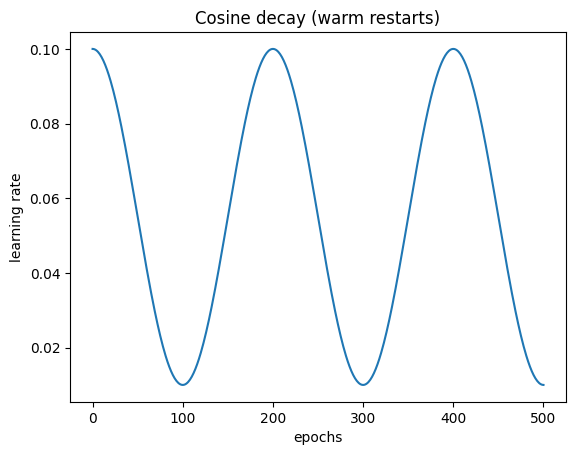

In [81]:
plt.plot(epoch, cosine_decay_1(epoch))
plt.title('Cosine decay (warm restarts)')
plt.xlabel('epochs')
plt.ylabel('learning rate')
plt.show()

Одновременно, эту же формулу можно записать и так

$$ \eta_k = \eta_{0} \cdot \left( (1-\alpha) \cdot \left( 1 + \cos \left( \frac{ \text{epoch} }{
\text{epochs} } \cdot \pi \right) \right) + \alpha \right) $$

В этом случае снижение размера шага происходит от $\eta_{0}$ до $(\alpha \cdot\eta_{0}).$

In [82]:
def cosine_decay_2(epoch, initial_lr = 0.1, epochs = 100, alpha = 0.1):
  cosine_decay = 0.5 * (1 + np.cos(np.pi * epoch / epochs))
  decayed = (1 - alpha) * cosine_decay + alpha
  return initial_lr * decayed

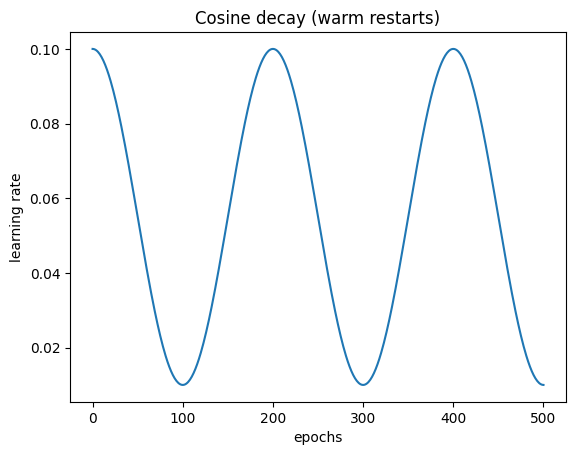

In [83]:
plt.plot(epoch, cosine_decay_2(epoch))
plt.title('Cosine decay (warm restarts)')
plt.xlabel('epochs')
plt.ylabel('learning rate')
plt.show()

Как мы видим размер шага снижается с $\eta_{0} = 0{,}1$ до $\alpha \cdot \eta_{0} =
0{,}1 \cdot 0{,}1 = 0{,}01.$

## Метод наискорейшего спуска
До сих пор мы так или иначе развивали идею стохастического градиентного спуска. Сделаем небольшое отступление и рассмотрим еще один метод оптимизации с изменяемым размером шага, который называется **методом наискорейшего спуска** (steepest descent method).

### Базовый алгоритм
Вначале выполним подготовительную работу. Возьмем те же данные, целевую функцию и ее градиент.

In [84]:
t_true = np.array([3.2, 2, -2.7, 1.6])
X, y = synth_reg_data(t_true)

In [85]:
def objective(x, y, thetas):
  return np.sum((y - np.dot(x, thetas))) ** 2 / (2 * len(x))

def gradient(x, y, thetas):
  return np.dot(x.T, (np.dot(x, thetas) - y)) * (1 / len(x))

Создадим алгоритм full batch градиентного спуска. Другими словами, будем выполнять обновление весов в направлении антиградиента (направлении наискорейшего спуска).

При этом внесем в этот хорошо знакомый алгоритм одно изменение. Прекратим обучение не только по достижении максимального количества шагов (max_iter), но и если градиент будет ниже околонулевого порога (tol), то есть алгоритм практически приблизится к оптимуму.

Кроме того, запишем количество затраченных шагов, чтобы, если сработает второе условие, понять как быстро алгоритм достиг почти нулевого градиента.

In [86]:
# пропишем начальный размер шага, порог для градиента и
# максимальное количество шагов
eta, tol, max_iter = 0.01, 1e-8, 10000

# зададим начальные параметры
theta = np.zeros(X.shape[1])
# и значение градиента при таких параметрах
grad_theta = gradient(X, y, theta)

step_count = 0

# пока не сработает одно из условий
# (напомню any() выдает True, если хотя бы один из параметров
# ниже порогового значения)
while any(abs(grad_theta) > tol) and step_count < max_iter:

  # обновим веса и
  theta = theta - eta * grad_theta
  # рассчитаем градиент в новой точке
  grad_theta = gradient(X, y, theta)

  step_count += 1

In [87]:
theta, step_count

(array([ 3.19981975,  2.00017025, -2.70026591,  1.59961898]), 1960)

Как мы видим, алгоритм нашел оптимальные параметры и затратил на это 1960 шагов. Возникает вопрос, как решить эту же задачу за меньшее количество итераций.

### Оптимальный размер шага

#### Одномерная оптимизация
Вполне очевидно, что уменьшить количество шагов можно за счет увеличения размера каждого отдельного шага. Для этого на каждом шаге «большого» алгоритма необходимо решить дополнительную задачу одномерной оптимизации относительно $\eta.$

$$ \min_{\eta} f(\theta^k + \eta \nabla \theta^k), $$

где $ \theta^k $ и $ \nabla \theta^k $ — значения весов и градиента на текущем шаге $k.$

#### Условия Вольфе
Одновременно необходимо задать условия выбора оптимального параметра $\eta.$ И действительно,
* если выбрать слишком большой шаг, алгоритм не сойдется к оптимуму;
* если размер шага будет недостаточным, алгоритм может не успеть дойти до минимума.

Таким образом, нам требуются два критерия:
1. уверенности, что значение функции уменьшится в новой точке $\theta_{k+1}$ (критерий достаточного убывания, sufficient decrease condition); а также
2. знания того, что размер шага не слишком мал (критерий кривизны, curvature condition).

Первый критерий называют **условием Армихо** (Armijo condition), а вместе эти критерии называют **условиями Вольфе** (Wolfe conditions). Более формально,

$$ f(\theta_k + \eta_k \cdot p_k) \leq f(\theta_k) + c_1 \eta_k (\nabla f_k^\top \cdot p_k),
$$

$$ \nabla f (\theta_k + \eta_k p_k)^\top \cdot p_k \geq c_2 (\nabla f_k^\top \cdot p_k) $$

где $p_k$ (в данном случае) направление антиградиента, то есть $p_k = -\nabla f(\theta_k).$ При этом константы $c_1$ и $c_2$ выбираются таким образом, чтобы $0 < c_1 < c_2 < 1.$ Подробное рассмотрение этих правил выходит за рамки сегодняшнего занятия.

### Обратный линейный поиск
Подобрать оптимальный размер шага можно с помощью **обратного линейного поиска** (backtracking line search), при котором мы, как правило, начинаем с $\eta = 1$ и затем уменьшаем размер шага (например, в два раза) до тех пор, пока не будет
выполнен критерий Армихо.

Интересно, что в этом случае достаточно указать только первый критерий, поскольку так как мы идем от большего размера шага к меньшему, то в любом случае выберем наибольшее возможное $\eta$ и, таким образом, обеспечим выполнение и второго критерия Вольфе.

Такой поиск оптимального $\eta$ называется приближенным линейным поиском (inexact line search), поскольку дает не точную, а достаточную оценку оптимального размера шага $\eta$ на каждой итерации «большого» алгоритма.

Реализуем эту идею на Питоне и попробуем найти оптимальные параметры $\theta$ за меньшее количество шагов.

In [88]:
# пропишем алгоритм обратного линейного поиска
def line_search(eta, theta, grad_theta, x, y, c1 = 1e-4):

  # найдем значение целевой функции на шаге k
  objective_theta = objective(x, y, theta)

  # найдем значение целевой функции на шаге k+1
  objective_theta_new = objective(x, y, theta - eta * grad_theta)

  # найдем квадрат длины вектора (скалярное произведение)
  grad_sq = np.dot(grad_theta, grad_theta)

  # зададим условие, обратное условию Армихо
  not_armijo = objective_theta_new >= (objective_theta - c1 * eta * grad_sq)

  # пока истинно обратное условие,
  # будем уменьшать eta в два раза
  while not_armijo:
    eta *= 0.5

  return eta

In [89]:
# зададим порог значения градиента и
# максимальное количество итераций
tol, max_iter = 1e-8, 10000

# зададим начальные значения параметров и
theta = np.zeros(X.shape[1])
# начальный градиент
grad_theta = gradient(X, y, theta)

step_count = 0

# пока не сработает одно из условий
while any(abs(grad_theta) > tol) and step_count < max_iter:

  # будем искать оптимальное значение eta,
  # начиная с единицы
  eta_0 = 1
  eta = line_search(eta_0, theta, grad_theta, X, y)

  # обновлять веса и
  theta = theta - eta * grad_theta
  # обновлять градиент
  grad_theta = gradient(X, y, theta)

  step_count += 1

In [90]:
theta, step_count

(array([ 3.19981975,  2.00017025, -2.70026592,  1.59961898]), 8)

Метод наискорейшего спуска решил задачу за восемь шагов.

## Еще немного терминологии
### Классификация методов оптимизации
Итерационные методы оптимизации в зависимости от того, какая информация требуется для перехода от шага $k$ к шагу $k+1,$ можно разделить на:
* методы нулевого порядка (zero-order) или прямые методы, при которых требуется знать лишь значение целевой функции $f(\theta);$
* методы первого порядка (first-order), которые используют первую производную $f^{\prime}(\theta)$ (для одномерной функции) или градиент $\nabla f(\theta) $ (для многомерной);
* методы второго порядка (second-order), для которых необходимо знание второй производной $f^{\prime\prime}(\theta)$ или матрицы Гессе $\mathbf{H}f(\theta)$ (Гессиана функции, Hessian).
До сих пор мы подробно изучали методы первого порядка. В частности,
* метод градиентного спуска (в том числе SGD);
* метод координатного спуска; а также
* метод наискорейшего спуска.

Кроме этого скажем, что по характеру задачи методы делятся на:
* детерминированные (например, full batch градиентный спуск); и
* стохастические (SGD).

### Оракул в оптимизации
При выполнении задачи численной оптимизации мы не имеем полного
представления о целевой функции. Одновременно на каждой итерации метод может получать некоторую информацию о функции в точке $\theta_k.$ В частности, метод первого порядка может узнать значение функции и значение градиента.

Говорят, что в этом случае метод обращается к **оракулу** (oracle), абстрактной сущности, которая дает ***локальную*** информацию о функции в точке.

Например, можно говорить о классе стохастических оракулов первого порядка $\mathcal{O}$, в котором каждый оракул $ \varphi $ определяется через

$$ \varphi (\theta, f) = (\hat{f}(\theta), \hat{g}(\theta)), $$

где $ \hat{f}(\theta) $ и $ \hat{g}(\theta) $ представляют собой случайные величины и являются несмещенной оценкой значения функции и значения градиента в точке $\theta$ соответственно

$$ \mathbb{E} [ \hat{f}(\theta) ] = f(\theta), \quad \mathbb{E} [ \hat{g}(\theta) ] =
g(\theta) $$

##Промежуточный итог

Во второй части мы рассмотрели теоретическое обоснование уменьшения размера шага в методе стохастического градиентного спуска, а также изучили как на практике коэффициент скорости обучения может изменяться с помощью расписания.

Кроме этого, мы рассмотрели еще один градиентный метод — метод
наискорейшего спуска, ввели классификацию методов оптимизации и понятие оракула.

## Список литературы
* Stochastic Gradient Descent with Warm Restarts, Loshchilov & Hutter, 2017 (https://arxiv.org/pdf/1608.03983)
* On the Variance of the Adaptive Learning Rate and Beyond, Liu, 2021 (https://arxiv.org/pdf/1908.03265)

# Стохастический градиентный спуск. Часть 3

Во второй части мы узнали про важность изменения размера шага в алгоритме SGD. Продолжим улучшать стохастический градиентный спуск.

## Адаптивный размер шага
Попробуем изменять размер шага отдельно для каждого параметра $\theta_j.$ Посмотрим, для чего это может быть нужно.
### Разный наклон
Рассмотрим функцию $ f(\theta_1, \theta_2) = 5 \theta_1^2 + \theta_2^2.$ Очевидно, что наклон по первому измерению $\theta_1$ будет в пять раз больше, чем по второму $\theta_2.$

$$ \frac{ \partial }{ \partial \theta_1 } f( \theta_1, \theta_2 ) = 10 \theta_1, \quad \frac{
\partial }{ \partial \theta_2 } f( \theta_1, \theta_2 ) = 2 \theta_2 $$

Попробуем дойти до минимума методом градиентного спуска,
* подобрав относительно большой размер шага для обоих измерений;
* применив меньший размер шага также для обоих измерений; и наконец
* выбрав больший размер шага для измерения с меньшим наклоном и наоборот меньший шаг для большего наклона.

**Сценарий 1:** $\eta = 0{,}2$. Большой размер шага обеспечил уверенное продвижение по пологому второму измерению (по вертикали) и оказался избыточным для крутого наклона первого измерения (по горизонтали).

**Сценарий 2:** $\eta = 0{,}02$. Здесь наоборот, мы осторожно, но уверенно двигаемся по крутому первому измерению, и делаем очевидно недостаточные шаги по второму.

**Сценарий 3:** $\eta_1 = 0{,}02, \eta_2 = 0{,}2$. Если взять меньший шаг для большего наклона, и наоборот больший шаг для меньшего, то алгоритм быстрее сойдется к оптимуму.

### Разный наклон

Объявим частные производные для $f(\theta_1, \theta_2) = 5\theta_1^2 + \theta_2^2 $.

In [91]:
def partial_1(theta1):
  return 10.0 * theta1

def partial_2(theta2):
  return 2.0 * theta2

In [92]:
# зададим количество шагов
steps = 15

Сценарий 1: $\eta = 0{,}2$

In [93]:
# пропишем начальное значение параметров
theta1, theta2 = -15, 15
# в списки будет записывать их значение на каждом шаге
theta1_l1, theta2_l1 = [], []
# зададим размер шага
lr = 0.2

# на каждом шагу
for k in range(steps):

  # запишем текущие параметры
  theta1_l1.append(theta1)
  theta2_l1.append(theta2)

  # найдем частные производные
  par_1 = partial_1(theta1)
  par_2 = partial_2(theta2)

  # обновим параметры
  theta1 = theta1 - lr * par_1
  theta2 = theta2 - lr * par_2

Сценарий 2: $\eta = 0{,}02$

In [94]:
theta1, theta2 = -15, 15
theta1_l2, theta2_l2 = [], []
lr = 0.02

for k in range(steps):

  theta1_l2.append(theta1)
  theta2_l2.append(theta2)

  par_1 = partial_1(theta1)
  par_2 = partial_2(theta2)

  theta1 = theta1 - lr * par_1
  theta2 = theta2 - lr * par_2

Сценарий 3: $\eta_1 = 0{,}02, \eta_2 = 0{,}2$

In [95]:
theta1, theta2 = -15, 15
theta1_l3, theta2_l3 = [], []
lr1, lr2 = 0.02, 0.2

for k in range(steps):

  theta1_l3.append(theta1)
  theta2_l3.append(theta2)

  par_1 = partial_1(theta1)
  par_2 = partial_2(theta2)

  theta1 = theta1 - lr1 * par_1
  theta2 = theta2 - lr2 * par_2

Посмотрим на изменение параметров на графиках

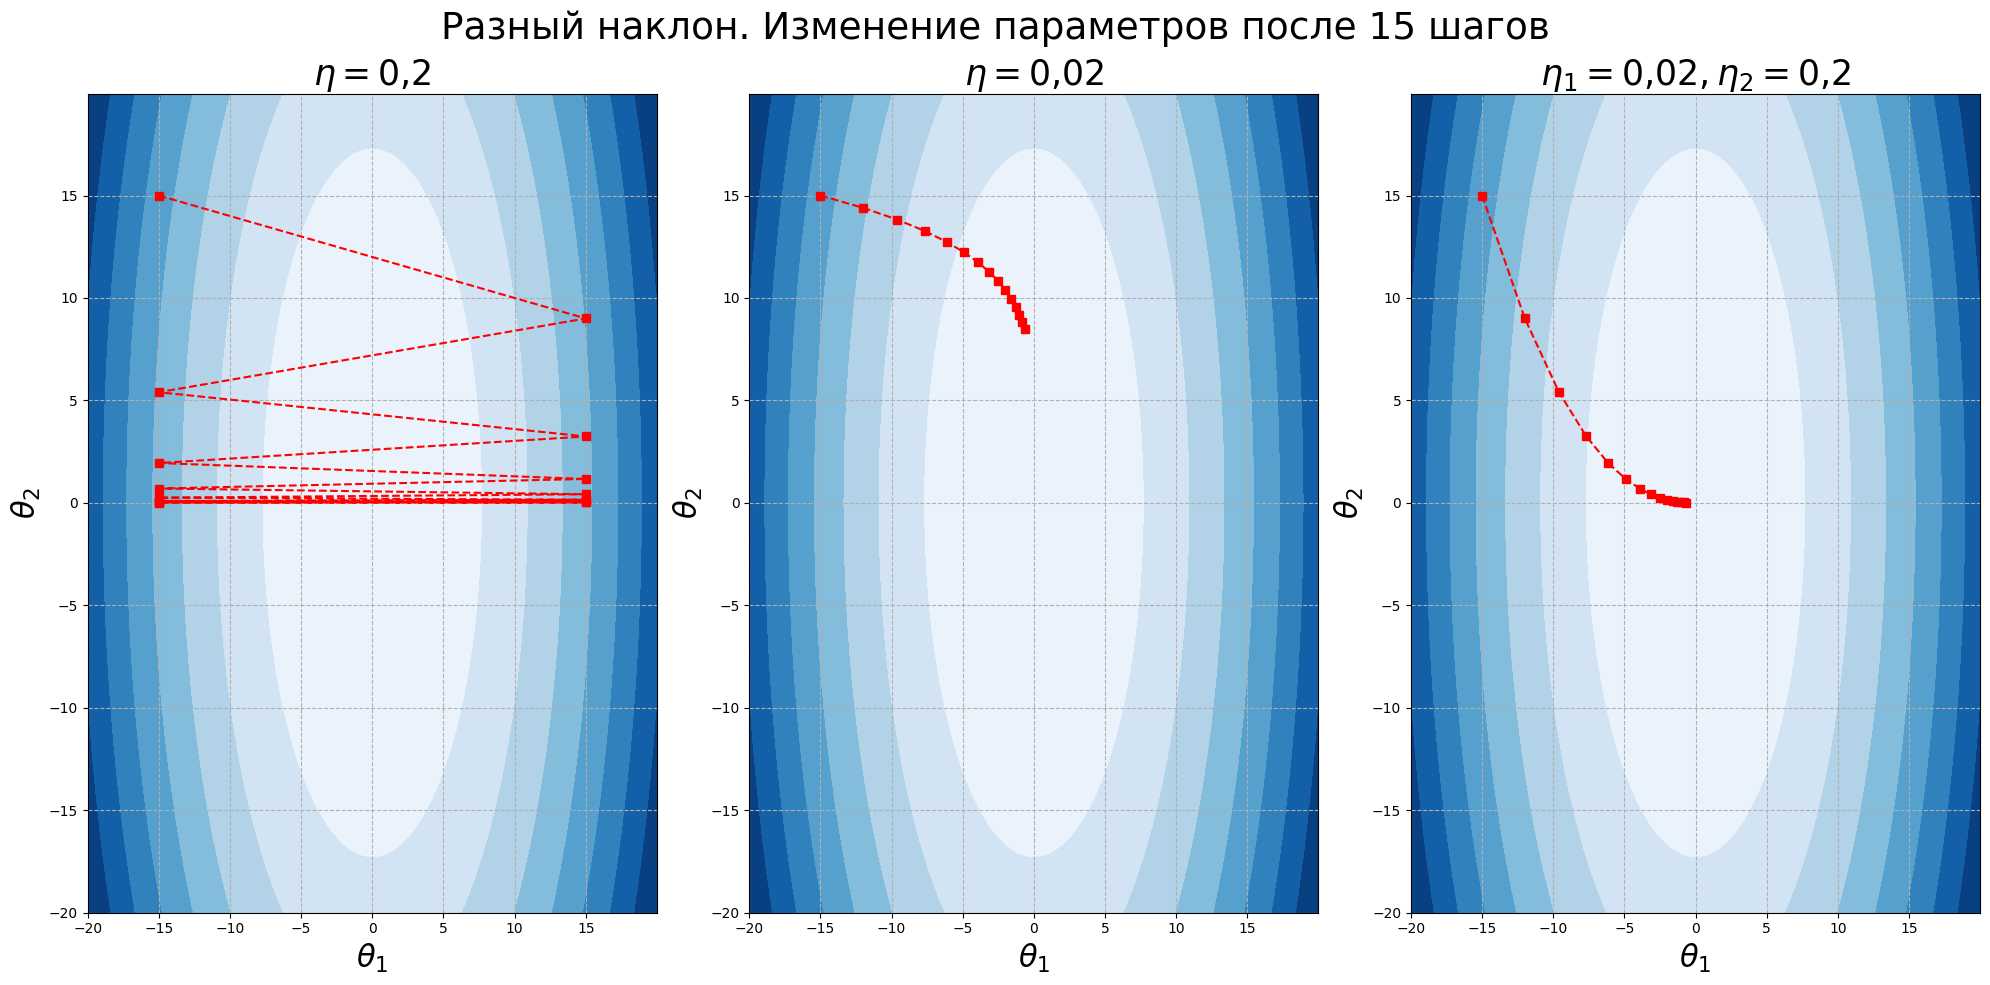

In [96]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3,
                                    figsize = (20, 10))

min, max = -20, 20
theta1_plot = np.arange(min, max, 0.02)
theta2_plot = np.arange(min, max, 0.02)

theta1_plot, theta2_plot = np.meshgrid(theta1_plot, theta2_plot)
f = 5 * theta1_plot ** 2 + theta2_plot ** 2

ax1.plot(theta1_l1, theta2_l1, c = 'red', linestyle = '--', marker = 's')
ax2.plot(theta1_l2, theta2_l2, c = 'red', linestyle = '--', marker = 's')
ax3.plot(theta1_l3, theta2_l3, c = 'red', linestyle = '--', marker = 's')

ax_titles = {ax1: r'$\eta = 0{,}2$',
             ax2: r'$\eta = 0{,}02$',
             ax3: r'$\eta_1 = 0{,}02, \eta_2 = 0{,}2$'}

for ax in (ax1, ax2, ax3):
  ax.set_title(ax_titles[ax], fontsize = 25)
  ax.contourf(theta1_plot, theta2_plot, f, cmap = 'Blues')
  ax.set_xlabel(r'$\theta_1$', fontsize = 22)
  ax.set_ylabel(r'$\theta_2$', fontsize = 22)
  ax.grid(linestyle = '--')

fig.suptitle(f'Разный наклон. Изменение параметров после {steps} шагов', fontsize = 27)
plt.tight_layout()
plt.show()

### Разреженные признаки

#### Первая иллюстрация

Рассмотрим разреженные данные (sparse data), в которых значения многих признаков равны нулю (**разреженные признаки**, sparse features).

$$ X = \begin{bmatrix} 1 & 0 \\ 5 & 0 \\ 2 & 2 \end{bmatrix}, \quad y = \begin{bmatrix}
2 \\ 1 \\ 1{,}5 \end{bmatrix} $$

Возьмем квадратичную целевую функцию и попробуем минимизировать ошибку методом стохастического градиентного спуска. Тогда,

$$ f_i({\theta}) = (X_i \theta-y_i)^2, $$

где $X_i$ — одно наблюдение (строка) матрицы $X.$ Градиент такой функции можно найти через

$$ \nabla f_i(\theta) = 2X_i^\top (X_i \theta-y_i) $$

При этом будем обновлять параметры согласно

$$ \theta^{k+1} := \theta^{k}-\eta \nabla f_i(\theta^k), $$

взяв (предположим, что случайно) сначала первое $i=1$, потом второе $i=2$ и наконец третье наблюдение $i=3.$ Зададим начальные веса и размер шага

$$ \theta^0 = \begin{bmatrix} 0 \\ 0 \end{bmatrix}, \quad \eta = 0{,}01 $$

Найдем градиент на первой итерации при $k=1$ и для первого наблюдения $i=1.$

$$ \nabla f_1(\theta^1) = 2 X_1^\top (X_1 \theta-y_1) = 2 \begin{bmatrix} 1 \\ 0
\end{bmatrix} (\begin{bmatrix} 1 & 0 \end{bmatrix}\begin{bmatrix} 0 \\ 0
\end{bmatrix}-2) = $$

$$ \begin{bmatrix} 2 \\ 0 \end{bmatrix} \cdot \begin{bmatrix} -2 \\ -2 \end{bmatrix} =
\begin{bmatrix} -4 \\ 0 \end{bmatrix} $$

Поскольку второй компонент градиента равен нулю, при переходе на второй шаг обновится только первый параметр.

$$ \theta^2 = \theta^1-\eta \nabla f_1(\theta^1) = \begin{bmatrix} 0 \\ 0
\end{bmatrix}-0{,}01 \begin{bmatrix} -4 \\ 0 \end{bmatrix} = \begin{bmatrix} 0{,}04 \\
0 \end{bmatrix}$$

На следующем шаге при $k=2$, так как $ X_2 = \begin{bmatrix} 5 & 0 \end{bmatrix}, $ второй компонент градиента снова будет равен нулю, и соответствующий параметр снова не обновится. Обновление произойдет только на третьем шаге $k=3.$

Проиллюстрируем этот процесс с помощью Питона и выведем значения весов и градиентов, дважды (т.е. в течение двух эпох) пройдясь по каждому из наблюдений.

In [97]:
def sparse_gradient(x, y, i, theta):
  return 2 * np.dot(x[i].T, (np.dot(x[i], theta) - y[i]))

In [98]:
X_s = np.array([
    [1, 0],
    [5, 0],
    [2, 2]
])

y_s = np.array([2, 1, 1.5])

In [99]:
eta = 0.01
theta_s = np.array([0, 0])
np.set_printoptions(precision = 2, floatmode = 'fixed')

for epoch in range(2):
  print('Epoch:', epoch+1)
  print('k', '\t', 'gradient', '\t', 'theta')
  for k in range(3):
    grad_s = sparse_gradient(X_s, y_s, k, theta_s)
    theta_s = theta_s - eta * grad_s
    print(k+1, '\t', grad_s, '\t', theta_s)
  print('--------------------------')

Epoch: 1
k 	 gradient 	 theta
1 	 [-4.00  0.00] 	 [0.04 0.00]
2 	 [-8.00  0.00] 	 [0.12 0.00]
3 	 [-5.04 -5.04] 	 [0.17 0.05]
--------------------------
Epoch: 2
k 	 gradient 	 theta
1 	 [-3.66  0.00] 	 [0.21 0.05]
2 	 [0.35 0.00] 	 [0.20 0.05]
3 	 [-3.97 -3.97] 	 [0.24 0.09]
--------------------------


Как мы видим, если значение признака равно нулю, соответствующий компонент градиента также равен нулю. В этой связи говорят не только про разреженные данные или признаки, но и про **разреженные градиенты** (sparse gradients).

Как следствие такой разреженности, второй параметр обновляется только один раз за эпоху.

Одновременно, поскольку размер шага для обоих признаков одинаковый, обновление весов второго признака будет «отставать», и в результате мы будем медленнее спускаться в разреженном измерении.

Это обстоятельство опять же наталкивает на мысль об использовании различных коэффициентов скорости обучения для разреженного и плотного (dense) или заполненного признаков.

#### Вторая иллюстрация

Рассмотрим функцию с одинаковым наклоном по каждому из измерений

$$ f(\theta_1, \theta_2) = \theta_1^2 + \theta_2^2$$

Также договоримся, что второй признак наполовину разрежен (половина наблюдений равна нулю). Имитируем это обстоятельство, обнуляя градиент при четных $k$ шагах градиентного спуска.

Будем минимизировать $f$ с (1) одинаковым для обоих измерений размером шага и (2) относительно бо́льшим размером шага для разреженного измерения и меньшим для плотного.

In [100]:
def partial_1(theta1):
  return 2.0 * theta1

def partial_2(theta2):
  return 2.0 * theta2

In [101]:
steps = 15

Сценарий 1: $\eta = 0{,}03$

In [102]:
theta1, theta2 = -15, 15
theta1_l1, theta2_l1 = [], []
lr = 0.03

for k in range(steps):

  if k % 2 == 0:
    sparse = 0
  else:
    sparse = 1

  theta1_l1.append(theta1)
  theta2_l1.append(theta2)

  par_1 = partial_1(theta1)
  par_2 = partial_2(theta2)

  theta1 = theta1 - lr * par_1
  theta2 = theta2 - lr * par_2 * sparse

Сценарий 2: $\eta_1 = 0{,}03, \eta_2 = 0{,}3$

In [103]:
theta1, theta2 = -15, 15
theta1_l2, theta2_l2 = [], []
lr1, lr2 = 0.03, 0.3

for k in range(steps):

  if k % 2 == 0:
    sparse = 0
  else:
    sparse = 1

  theta1_l2.append(theta1)
  theta2_l2.append(theta2)

  par_1 = partial_1(theta1)
  par_2 = partial_2(theta2)

  theta1 = theta1 - lr1 * par_1
  theta2 = theta2 - lr2 * par_2 * sparse

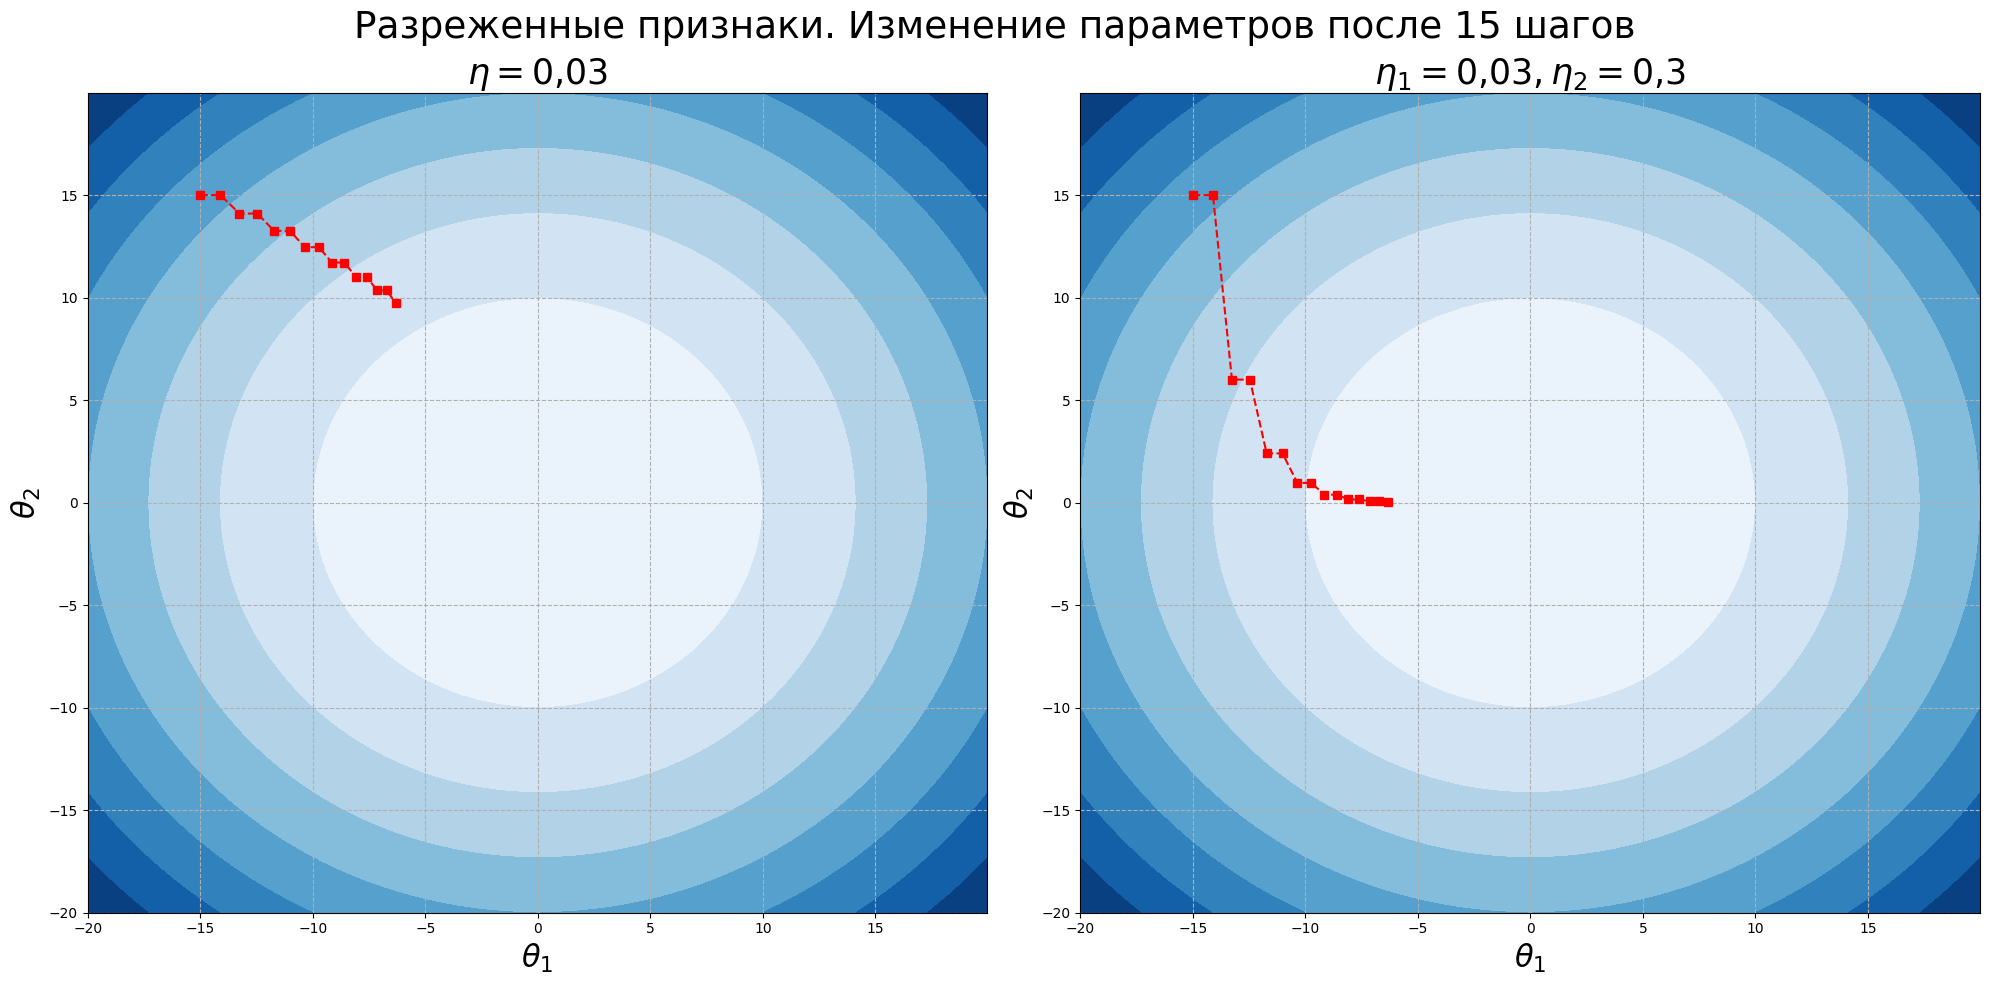

In [104]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2,
                               figsize = (20, 10))

min, max = -20, 20
theta1_plot = np.arange(min, max, 0.02)
theta2_plot = np.arange(min, max, 0.02)

theta1_plot, theta2_plot = np.meshgrid(theta1_plot, theta2_plot)
f = theta1_plot ** 2 + theta2_plot ** 2

ax1.plot(theta1_l1, theta2_l1, c = 'red', linestyle = '--', marker = 's')
ax2.plot(theta1_l2, theta2_l2, c = 'red', linestyle = '--', marker = 's')

ax_titles = {ax1: r'$\eta = 0{,}03$',
             ax2: r'$\eta_1 = 0{,}03, \eta_2 = 0{,}3$'}

for ax in (ax1, ax2):
  ax.set_title(ax_titles[ax], fontsize = 25)
  ax.contourf(theta1_plot, theta2_plot, f, cmap = 'Blues')
  ax.set_xlabel(r'$\theta_1$', fontsize = 22)
  ax.set_ylabel(r'$\theta_2$', fontsize = 22)
  ax.grid(linestyle = '--')

fig.suptitle(f'Разреженные признаки. Изменение параметров после {steps} шагов', fontsize = 27)
plt.tight_layout()
plt.show()

На графиках видно, что спуск по второму измерению (по вертикали) происходит реже. На четных итерациях мы двигаемся только по первому измерению (по горизонтали).

Для того чтобы компенсировать это обстоятельство, целесообразно делать больший шаг по разреженному измерению, когда редставится такая возможность (т.е. градиент не будет нулевым). Именно такой подход представлен на графике справа.

Теперь возникает следующий вопрос, как подобрать удачное значение $\eta$ для каждого параметра. Делать это вручную на реальных данных не представляется возможным.

### AdaGrad

Алгоритм **AdaGrad** (Adaptive Gradient) решает эту задачу посредством деления размера шага *каждог*о параметра $\theta_j$ на корень из суммы квадратов *соответствующих* этому параметру градиентов.

$$ v^k = v^{k-1} + \nabla f_i(\theta^k)^2 $$

$$ \theta^{k+1} := \theta^k-\frac{\eta}{\sqrt{v^k+\varepsilon}} \odot \nabla
f_i(\theta^k), $$

где $\varepsilon$ — небольшая константа, добавляемая для вычислительной устойчивости алгоритма. Если обозначить градиент на шаге $k$ через $g(k)$, то формулу для наглядности можно записать и так

$$ G(K) = \sum^K_{k=1} g(k)^2 $$

$$ \theta^{k+1} = \theta^k-\frac{\eta}{\sqrt{G(K)+\varepsilon}} \odot g(k)$$

Обратим внимание, что возведение в квадрат и умножение $\odot$ (произведение Адамара) покомпонентные. Другими словами,

$$ \begin{bmatrix} G(K)_1 \\ G(K)_2 \\ \vdots \\ G(K)_j \end{bmatrix} =
\begin{bmatrix} g(k)_1^2 \\ g(k)_2^2 \\ \vdots \\ g(k)_j^2 \end{bmatrix} +
\begin{bmatrix} g(k-1)_1^2 \\ g(k-1)_2^2 \\ \vdots \\ g(k-1)_j^2 \end{bmatrix} + \ldots +
\begin{bmatrix} g(1)_1^2 \\ g(1)_2^2 \\ \vdots \\ g(1)_j^2 \end{bmatrix} $$

$$ \begin{bmatrix} \theta^{k+1}_1 \\ \theta^{k+1}_2 \\ \vdots \\ \theta^{k+1}_j
\end{bmatrix} = \begin{bmatrix} \theta^{k}_1 \\ \theta^{k}_2 \\ \vdots \\ \theta^{k}_j
\end{bmatrix}-\begin{bmatrix} \frac{\eta}{\sqrt{G(K)_1+\varepsilon}} \\ \frac{\eta}
{\sqrt{G(K)_2+\varepsilon}} \\ \vdots \\ \frac{\eta}{\sqrt{G(K)_j+\varepsilon}}
\end{bmatrix} \odot \begin{bmatrix} g(k)_1 \\ g(k)_2 \\ \vdots \\ g(k)_j \end{bmatrix} $$

Таким образом, чем больше предыдущие градиенты (крутой склон или
заполненные данные) конкретного параметра $\theta_j,$ тем сильнее уменьшается соответствующий размер шага. При этом перед началом обучения достаточно задать единственный параметр $\eta.$

In [105]:
def gradient(x, y, thetas, n):
  return np.dot(x.T, (np.dot(x, thetas) - y)) * (1 / n)

In [106]:
def fit_adagrad(x, y, t_opt, batch_size, epochs = 50, lr = 1):

  x, y = x.copy(), y.copy()
  thetas = np.zeros(x.shape[1])

  G = np.zeros(x.shape[1])
  eps = 1e-8

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      grad = gradient(x_b, y_b, thetas, n)
      G += grad ** 2
      thetas -= lr / (np.sqrt(G + eps)) * grad

  return dist_to_opt

In [107]:
dist_adagrad = fit_adagrad(X, y, t_true,
                           batch_size = 1, epochs = 100,
                           lr = 1)

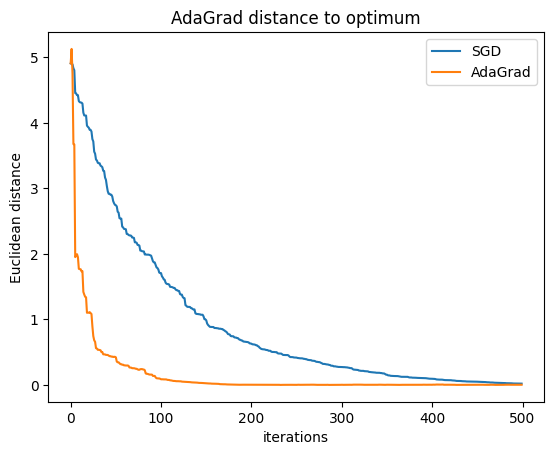

In [108]:
plt.plot(dist_sgd[:500], label = 'SGD')
plt.plot(dist_adagrad[:500], label = 'AdaGrad')
plt.title('AdaGrad distance to optimum')
plt.xlabel('iterations')
plt.ylabel('Euclidean distance')
plt.legend()
plt.show()

Обратите внимание, что мы взяли необычно большой начальный размер шага $\eta = 1$. На практике, кумулятивная сумма квадратов градиентов может так быстро увеличиться, что приблизит размер шага к нулю и, таким образом, замедлит
обучение.

Попробуем преодолеть этот недостаток, взглянув на процесс обучения методом SGD под несколько другим углом.

## Первый и второй моменты градиента
Cтохастические градиенты или mini batches в процессе обучения можно рассматривать как независимые одинаково распредёленные (i.i.d.) значения некоторой случайной величины, а совокупность этих градиентов — как соответствующее распределение.

И действительно, то, какое значение градиента мы получим на шаге $k$ случайно и зависит от того, какое $i_k$-ое наблюдение или какой $I_k$ mini batch нам достанется.
![](https://drive.google.com/uc?export=view&id=1XpaD9d5jdBIstf93KtnhbOkfxaw2jGiD)

Наблюдаемые же на шаге $k$ значения градиента, то есть те градиенты, которые уже были рассчитаны на $1, 2, \ldots, k-1, k$ шагах, можно считать выборкой, по которой мы будем оценивать данное распределение.

#### Моменты случайной величины
Распределение можно оценить, в частности, через выборочное среднее или дисперсию. Одновременно, в более общем смысле, для численной оценки можно использовать **моменты** (moments) случайной величины.
Для случайной величины $X$ $p$-ые моменты выборки размером $N$ можно найти по формуле

$$ m_p = \frac{1}{N} \sum^N_{n=1} (x_n-c)^p, $$

где $c$ — константа, относительно которой рассчитывается момент $m_p.$

**Начальный момент** (raw moment) характеризует распределение вокруг нуля, т.е. $c=0.$ Первый начальный момент (first raw moment) $m’_1,$ со степенью $p=1$ или среднее значение (mean) выборки можно найти по формуле

$$ m’_1 = \frac{1}{N} \sum^N_{n=1} (x_n-0)^1 $$

И действительно, если значения выборки равны $\{ 3, 2, 4, 1 \},$ ее первый начальный момент будет равен

$$ m’_1 = \frac{1}{N} \sum^N_{n=1} (x_n-0)^1 = \frac{3^1}{4} + \frac{2^1}{4} +
\frac{4^1}{4} + \frac{1^1}{4} = $$

$$ \frac{3^1 + 2^1 + 4^1 + 1^1}{4} = 2{,}5$$

Когда мы хотим оценить разброс значений, то обращаемся ко второму моменту со степенью $p=2.$

$$ m_2 = \frac{1}{N} \sum^N_{n=1} (x_n-c)^2 $$

При этом в большинстве случаев нас интересует разброс относительно среднего значения или центра распределения $c=m’_1$, поэтому мы обратимся не ко второму начальному, а ко второму **центральному моменту** (second central moment).

$$ m_2 = \frac{1}{N} \sum^N_{n=1} (x_n-m’_1)^2 $$

Для приведенной выше выборки получим

$$ m_2 = \frac{1}{N} \sum^N_{n=1} (x_n-2{,}5)^2 = $$

$$ \frac{(3-2{,}5)^2}{4} + \frac{(2-2{,}5)^2}{4} + \frac{(4-2{,}5)^2}{4} + \frac{(1-
2{,}5)^2}{4} = 1{,}25 $$

Второй центральный момент получил название дисперсия (variance). При этом ничто не мешает нам рассчитать второй начальный момент (second raw moment) $m’_2.$ Для этого нужно положить среднее значение $m’_1 = 0.$

$$ m’_2 = \frac{1}{N} \sum^N_{n=1} (x_n-0)^2 = $$

$$ \frac{(3-0)^2}{4} + \frac{(2-0)^2}{4} + \frac{(4-0)^2}{4} + \frac{(1-0)^2}{4} =
7{,}5 $$


In [109]:
sample1 = np.array([3, 2, 4, 1])
m1_prime = np.mean(sample1)
m2_prime = sum([x**2 for x in sample1]) / len(sample1)
# приведем расчет дисперсии без поправки Бесселя
m2 = np.var(sample1, ddof = 0)
m1_prime, m2_prime, m2

(np.float64(2.5), np.float64(7.5), np.float64(1.25))

Если бы значения выборки были $\{ 3, 2, 1, 1 \},$ то
$$ m_2 = 0{,}6875, \quad m’_2 = 3{,}75$$

In [110]:
sample2 = np.array([3, 2, 1, 1])
m1_prime = np.mean(sample2)
m2_prime = sum([x**2 for x in sample2]) / len(sample2)
m2 = np.var(sample2, ddof = 0)
m1_prime, m2_prime, m2

(np.float64(1.75), np.float64(3.75), np.float64(0.6875))

На практике чаще используется именно дисперсия $ m_2,$ а не второй начальный момент $m’_2,$ потому что так мы можем сравнивать разброс двух случайных величин.

In [111]:
np.random.seed(42)

# возьмем выборки распределения роста взрослых и детей
# пусть СКО роста взрослых будет меньше, чем СКО роста детей
adults = np.random.normal(180, 2, size = 1000)
children = np.random.normal(120, 3, size = 1000)

In [112]:
# тем не менее второй начальный момент
# роста взрослых больше
m2_prime_adults = (adults**2).mean()
m2_prime_children = (children**2).mean()
print(f'{m2_prime_adults:.2f}\t{m2_prime_children:.2f}')

32417.75	14459.99


In [113]:
# второй центральный момент (дисперсия) при этом
# ожидаемо больше у детей
m2_adults = adults.var(ddof = 0)
m2_children = children.var(ddof = 0)
print(f'{m2_adults:.2f}\t{m2_children:.2f}')

3.83	8.95


Если же сравнение не требуется, то мы можем ограничиться вторым начальным моментом случайной величины для характеристики ее изменчивости.

Приведем таблицу первого и второго начального и центрального моментов.
![](https://drive.google.com/uc?export=view&id=19FqXLRMHCYyBP6dXiWEjUyDZkrtyjhpM)

Дополнительно заметим, что первый центральный момент $m_1$ не слишком информативен, так как всегда равен нулю.

$$ m_1 = \frac{1}{N} \sum^N_{n=1} (x_n-m’_1)^1 = 0 $$

In [114]:
m1 = sum([x-sample2.mean() for x in sample2]) / len(sample2)
m1

np.float64(0.0)

### Первый момент градиента
Поскольку мы договорились считать каждый стохастический градиент или mini batch одного параметра значением случайной величины $g^k,$ то можем оценить ее первый начальный момент по уже известным нам первым $K$ значениям.

$$ m’_1 = \frac{1}{K} \sum^{K}_{k=1} (\nabla f_i (\theta_j)-0)^1 $$

Недостатком такого подхода является то, что мы задаем одинаковый вес всем предыдущим значениям градиентов (выборке). Это не оправданно, поскольку ландшафт функции потерь мог измениться, и было бы более логично отдать предполчение недавним значениям.

Для этого применим экспоненциально взвешенное скользящее среднее и найдем первый начальный момент на шаге $k.$

$$ (m’_1)^k = \beta (m’_1)^{k-1} + (1-\beta) \nabla f_i (\theta_j^{k}) $$

Упростим нотацию, положив $(m’_1) = m,$

$$ m^k = \beta m^{k-1} + (1-\beta) \nabla f_i (\theta_j^{k}) $$

и перед нами метод SGD с инерцией.

Таким образом, стохастический градиентный спуск с инерцией использует оценку первого начального момента распределения $ \nabla f_i (\theta_j) $ для каждого последующего обновления параметра $\theta_j.$
### Второй момент градиента
Оценка второго начального момента случайной величины представляет собой квадрат соответствующих значений вектора градиента.

$$ m’_2 = \frac{1}{K} \sum^{K}_{k=1} (\nabla f_i (\theta_j)-0)^2, $$

то есть по сути компонент $G(K)$ алгоритма Adagrad с тем отличием, что мы не делим на количество $K$ шагов.

### RMSProp

Такое (экспоненциальное) усреднение вводится алгоритмом **RMSprop** (Root Mean Squared Propagation).

$$ v^k = \beta v^{k-1} + (1-\beta) g(k)^2 $$

$$ \theta^{k+1} = \theta^k-\frac{\eta}{\sqrt{v^k+\varepsilon}} \odot g(k)$$

Так же как и в случае с SGD с инерцией мы обращаем больше внимания на недавние градиенты, только здесь в зависимости от этого корректируем размер шага.

In [115]:
def fit_rmsprop(x, y, t_opt, batch_size,
                epochs = 50, lr = 0.01, beta = 0.9):

  x, y = x.copy(), y.copy()
  thetas = np.zeros(x.shape[1])

  vk = np.zeros(x.shape[1])
  eps = 1e-8

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      grad = gradient(x_b, y_b, thetas, n)
      vk = beta * vk + (1 - beta) * np.square(grad)
      thetas -= (lr / np.sqrt(vk + eps)) * grad

  return dist_to_opt

## Алгоритм Adam
Алгоритм **Ada**m (Adaptive Moment Estimation, т.е. «адаптивная оценка моментов [случайной величины]») объединяет многие из высказанных ранее идей улучшения стохастического градиентного спуска.

В частности, алгоритм учитывает инерцию (первый начальный момент)

$$ m^k = \beta_1 m^{k-1} + (1-\beta_1) g(k), $$

а также изменчивость градиента (второй начальный момент)

$$ v^k = \beta_2 v^{k-1} + (1-\beta_2) g(k)^2, $$

вводит корректировку экспоненциального сглаживания как первого $\hat{m}^k,$ так и второго $\hat{v}^k$ моментов

$$ \hat{m}^k = \frac{m^k}{1-\beta_1^k}, \quad \hat{v}^k = \frac{v^k}{1-\beta_2^k} $$

и наконец обновляет веса, корректируя направление и размер шага,

$$ \theta^{k+1} := \theta^k-\eta \frac{\hat{m}^k }{\sqrt{\hat{v}^k}+\varepsilon}. $$

Таким образом, алгоритм снабжен тремя гиперпараметрами:
* размером шага $\eta;$ а также
* двумя коэффициентами затухания, которые авторы алгоритма рекомендуют по умолчанию установить на уровне $\beta_1 = 0{,}9, \beta_2 = 0{,}999.$

Опять же, умножение векторов поэлементное.

In [116]:
def fit_adam(x, y, t_opt, batch_size, epochs = 50,
             lr = 0.1,
             beta1 = 0.9, beta2 = 0.999):

  x, y = x.copy(), y.copy()
  thetas = np.zeros(x.shape[1])

  mk = np.zeros(x.shape[1])
  vk = np.zeros(x.shape[1])
  eps = 1e-8
  k = 1

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      grad = gradient(x_b, y_b, thetas, n)

      mk = beta1 * mk + (1 - beta1) * grad
      vk = beta2 * vk + (1 - beta2) * np.square(grad)

      mhat = mk / (1 - beta1 ** k )
      vhat = vk / (1 - beta2 ** k )

      thetas -= lr * mhat/(np.sqrt(vhat) + eps)
      k += 1

  return dist_to_opt

In [117]:
dist_adam = fit_adam(X, y, t_true, batch_size = 1)

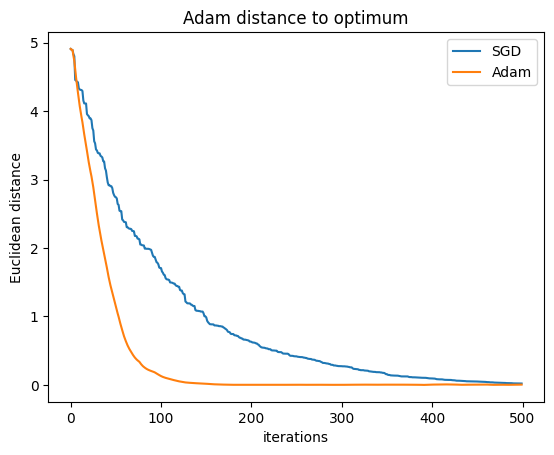

In [118]:
plt.plot(dist_sgd[:500], label = 'SGD')
plt.plot(dist_adam[:500], label = 'Adam')
plt.title('Adam distance to optimum')
plt.xlabel('iterations')
plt.ylabel('Euclidean distance')
plt.legend()
plt.show()

Рассмотрим некоторые идеи развития этого алгоритма.

### AdaMax

Интересно, что второй начальный момент $v^k$ можно представить как
экспоненциально взвешенную (до извлечения корня) $L_2$ норму вектора
значений текущего и прошлых градиентов $ L_2 = (v^k)^{\frac{1}{2}}. $
Тогда в общем виде $L_p$ норму $ (v^k)^{\frac{1}{p}} $ можно записать как
$$ || \textbf{x} ||_p = \left( \sum_{i=1}^n { |x_i|^p } \right)^{\frac{1}{p}}
\longrightarrow (v^k)^{\frac{1}{p}} = \biggl( \beta^p_2 v^{k-1} + (1-\beta^p_2)|g(k)|^p
\biggr)^{\frac{1}{p}} $$
Обратите внимание, $\beta_2 \rightarrow \beta_2^p.$ Тогда по формуле
экспоненциально взвешенного скользящего среднего
$$ (v^k)^{\frac{1}{p}} = \biggl( (1-\beta_2^p) \sum^k_{i=1} \beta_2^{p(k-i)} \cdot
|g_i|^p \biggr)^{\frac{1}{p}} $$

Положив $u^k = \lim_{p \to \infty} (v^k)^{\frac{1}{p}}$ (расстояние Чебышёва), получим

$$ \begin{array}{ll} u^k = & \lim_{p \to \infty} (v^k)^{\frac{1}{p}} = \\ & \lim_{p \to
\infty} \biggl( (1-\beta^p_2) \sum^k_{i=1} \beta_2^{p(k-i)} \cdot |g_i|^p
\biggr)^{\frac{1}{p}} = \\ & \lim_{p \to \infty} \underbrace { (1-\beta_2^p)^{\frac{1}
{p}} }_{1} \biggl( \sum^k_{i=1} \beta_2^{p(k-i)} \cdot |g_i|^p \biggr)^{\frac{1}{p}} =
\\ & \lim_{p \to \infty} \biggl( \sum^k_{i=1} \beta_2^{p(k-i)} \cdot |g_i|^p
\biggr)^{\frac{1}{p}} \end{array} $$

Расстояние Чебышёва можно найти через максимальное абсолютное значение координат вектора

$$ \lim_{p\to\infty} \left( \sum_{i=1}^n { |x_i|^p } \right) ^{\frac{1}{p}} =
\max_{i=1}^n | x_i | $$

Покажем это неформально. Пусть дан вектор $ \textbf{x} = [ 1, 2, 3]. $ Тогда по формуле нормы вектора

$$ || \textbf{x} ||_p = (1^p + 2^p + 3^p)^{\frac{1}{p}} = 3 \cdot \left( \left( \frac{1}{3}
\right)^p + \left( \frac{2}{3} \right)^p + 1 \right)^{1/p} $$

При $p \to \infty; \left( \frac{1}{3} \right)^p, \left( \frac{2}{3} \right)^p \to 0,$ а значит $ || \textbf{x} ||_p \to 3 .$

Приведем более формальное доказательство. Пусть $ \textbf{x} = [ x_1, x_2, \ldots, x_n ] $ — вектор с конечным числом элементов.

Допустим (поскольку $ \textbf{x} $ конечен), $0 \leq x_1 \leq x_2 \leq \dots \leq x_n$ так, что $x_n = \max_i | x_i|.$

При $ x_n = 0, $

$$\forall p \geq 1, \qquad 0 = || x ||_p \xrightarrow[p \to \infty] \; 0 = x_n$$

Если $x_n > 0,$

$$ \forall p\geq 1, \qquad \lVert x\rVert_p = x_n\left( \sum_{k=1}^{n} \left(\frac{x_k}
{x_n}\right)^p \right)^{\frac{1}{p}} $$

Поскольку $\forall k, 1 \leq k \leq n$ выполняется $0 \leq \frac{x_k}{x_n} \leq 1,$ получаем, что $ || x ||_p $ имеет следующие нижнюю и верхнюю границу

$$ \forall p\geq 1, \qquad x_n \cdot 1^{\frac{1}{p}} \leq || x ||_p \leq x_n \cdot
n^{\frac{1}{p}} $$

В силу того, что $ \lim_{p \to \infty} 1^{\frac{1}{p}} = 1 $ и $ \lim_{p \to \infty}
n^{\frac{1}{p}} = 1, $ по теореме о двух милиционерах получаем, что

$$ \lim_{p \to \infty} || x ||_p = x_n = \max_i | x_i|. $$

В случае значений градиента получим следующие аналитическую и рекуррентную формулы

$$ \begin{array}{ll} u^k & = & \max(\beta_2^{k-1} | g(1) |, \beta_2^{k-2} | g(2) |, \ldots,
\beta_2 |g(k-1)|, |g(k)|) \\ & = & \max (\beta_2 \cdot u^{k-1}, |g(k)|) \end{array} $$

Такой алгоритм, использующий для масштабирования размера шага наибольший по модулю экспоненциально сглаженный градиент, по понятной причине называется **AdaMax**.

Найдем первый и второй моменты.

$$ \begin{array}{ll} m^k & = & \beta_1 m^{k-1} + (1-\beta_1) g(k) \\ u^k & = &
\beta_2^\infty v^{k-1} + (1-\beta_2^\infty) |g(k)|^{\infty} \\ & = & \max(\beta_2 \cdot
v^{k-1}, |g(k)|) \end{array} $$

Сделаем коррекцию смещения первого момента относительно размера шага.

$$ \hat{\eta} = \frac{ \eta }{ (1-\beta_1^k) } $$

В силу того, что $u_0$ (в данном случае равное нулю) не влияет на расчет последующих $u^k$ значений, корректировка смещения этого компонента не требуется. Наконец обновим веса.

$$ \theta^{k+1} := \theta^k-\hat{\eta} \frac{m^k }{u^k} $$

In [119]:
def fit_adamax(x, y, t_opt, batch_size, epochs = 50,
               lr = 0.01,
               beta1 = 0.9, beta2 = 0.999):

  x, y = x.copy(), y.copy()
  thetas = np.zeros(x.shape[1])

  mk = np.zeros(x.shape[1])
  uk = np.zeros(x.shape[1])
  k = 1

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      grad = gradient(x_b, y_b, thetas, n)

      mk = beta1 * mk + (1 - beta1) * grad
      uk = np.max([beta2 * uk, np.abs(grad)], axis=0)

      lr_hat = lr / (1 - beta2 ** k)
      k += 1

      thetas -= lr_hat * mk/uk

  return dist_to_opt

### AdamW
$$\require{cancel}$$
Рассмотрим применение регуляризующих слагаемых к упомянутым алгоритмам оптимизации. В случае L2 регуляризации речь идет о

$$ \hat{f} (\theta) = f(\theta) + \frac { \lambda’ }{2} || \theta ||^2_2, $$

где $ \lambda’ = \frac {\lambda}{\eta}, $ $\lambda$ — коэффициент регуляризации, а $\eta$ — размер шага. Как следствие, производная будет иметь вид

$$ \nabla \hat{f} (\theta) = \nabla f(\theta) + \lambda’ \theta $$

Обновление параметров при этом будет происходить согласно

$$ \begin{array}{ll} \theta^{k+1} & := & \theta^k-\eta \nabla \hat{f} (\theta) \\ & := &
\theta^k-\eta ( \nabla f(\theta) + \lambda’ \theta ) \\ & := & \theta^k-\eta \nabla f(\theta)-
\lambda \theta, \end{array} $$

Как мы видим, обновленные параметры дополнительно уменьшаются на величину
$\lambda \theta,$ в силу чего регуляризацию еще называют убыванием весов (weight
decay), а $\lambda$ соответственно скоростью убывания (decay rate).

При этом если для классического SGD L2 регуляризация (добавление $\lambda’
\theta$ к функции потерь) и weight decay (уменьшение весов на $\lambda \theta$) —
это одно и то же (выше мы это показали), то в случае более сложных оптимизаторов это не так.

Рассмотрим алгоритм Adam и применим L2 регуляризацию. Найдем первый момент $ m^k $

$$ m^k = \beta_1 m^{k-1} + (1-\beta_1) (\nabla f(\theta) + \lambda \theta) $$

и подставим его в правило обновления весов

$$ \begin{array}{ll} \theta^{k+1} & := & \theta^{k}-\eta \left( \beta_1 m^{k-1} + (1-
\beta_1) (\nabla f(\theta) + \lambda’ \theta) \right) \\ & := & \theta^{k}-\eta \beta_1 m^{k-
1}-\eta (1-\beta_1) (\nabla f(\theta) + \lambda’ \theta) \\ & := & \theta^{k}-\eta \beta_1
m^{k-1}-\eta (1-\beta_1) \nabla f(\theta)-\lambda (1-\beta_1) \theta \end{array} $$

В таком виде регуляризация участвует в расчете экспоненциального среднего и, как следствие, не равна убыванию весов. Аналогичная сложность возникает при расчете второго момента $v^k.$

Авторы алгоритма **AdamW** предлагают использовать «отсоединенное» убывание весов (decoupled weight decay). Функция потерь и соответственно градиент рассчитываются без учета регуляризации

$$ g(k) = \nabla f(\theta^k) + \cancel{ \lambda \theta^k } $$

Расчет первого и второго момента аналогичен алгоритму Adam

$$ m^k = \beta_1 m^{k-1} + (1-\beta_1) g(k) $$

$$ v^k = \beta_2 v^{k-1} + (1-\beta_2) g(k)^2 $$

$$ \hat{m}^k = \frac{m^k}{1-\beta_1^k}, \quad \hat{v}^k = \frac{v^k}{1-\beta_2^k} $$

и только при обновлении весов появляется регуляризация

$$ \theta^{k+1} := \theta^k-\eta \frac{\hat{m}^k }{\sqrt{\hat{v}^k}+\varepsilon}-
{\color{Orange} \lambda \theta^{k} } $$

Исследование авторов AdamW показывает, что результаты алгоритмов с отсоединенным убыванием весов на тестовых данных на 15% выше, чем у L2 регуляризации.

Сравните код ниже.

Здесь приведена разница, а код ниже.

```
# L2 регуляризация
# reg - коэффициент регуляризации
grad = gradient(x_b, y_b, thetas, n) + reg * thetas
mk = beta1 * mk + (1 - beta1) * grad
vk = beta2 * vk + (1 - beta2) * np.square(grad)
mhat = mk / (1 - beta1 ** k)
vhat = vk / (1 - beta2 ** k)
thetas -= lr * mhat/(np.sqrt(vhat) + eps)
```

```
grad = gradient(x_b, y_b, thetas, n)
mk = beta1 * mk + (1 - beta1) * grad
vk = beta2 * vk + (1 - beta2) * np.square(grad)
mhat = mk / (1 - beta1 ** k)
vhat = vk / (1 - beta2 ** k)
# weight decay
thetas -= (lr * mhat/(np.sqrt(vhat) + eps) + reg * thetas)
```
Помимо AdamW decoupled weight decay очевидно можно применить и к другим оптимизаторам, например, к SGDm, AdaGrad или RMSProp.




In [121]:
def fit_adam_l2(x, y, t_opt, batch_size, epochs = 50, lr = 0.1,
                beta1 = 0.9, beta2 = 0.999, reg = 0.001):

  x, y = x.copy(), y.copy()
  thetas = np.zeros(x.shape[1])

  mk = np.zeros(x.shape[1])
  vk = np.zeros(x.shape[1])
  eps = 1e-8
  i = 1

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      # L2 регуляризация
      grad = gradient(x_b, y_b, thetas, n) + reg * thetas

      mk = beta1 * mk + (1 - beta1) * grad
      vk = beta2 * vk + (1 - beta2) * np.square(grad)

      mhat = mk / (1 - beta1 ** k)
      vhat = vk / (1 - beta2 ** k)

      thetas -= lr * mhat/(np.sqrt(vhat) + eps)
      k += 1

  return dist_to_opt

Weight decay

In [122]:
def fit_adamw(x, y, t_opt, batch_size, epochs = 50, lr = 0.1,
              beta1 = 0.9, beta2 = 0.999, reg = 0.001):

  x, y = x.copy(), y.copy()
  thetas = np.zeros(x.shape[1])

  mk = np.zeros(x.shape[1])
  vk = np.zeros(x.shape[1])
  eps = 1e-8
  k = 1

  dist_to_opt = []

  for epoch in range(epochs):
    batches = create_batches(x, y, batch_size)
    for x_b, y_b in batches:

      n = x_b.shape[0]
      dist_to_opt.append(np.linalg.norm(thetas - t_opt))

      grad = gradient(x_b, y_b, thetas, n)

      mk = beta1 * mk + (1 - beta1) * grad
      vk = beta2 * vk + (1 - beta2) * np.square(grad)

      mhat = mk / (1 - beta1 ** k)
      vhat = vk / (1 - beta2 ** k)

      # weight decay
      thetas -= (lr * mhat/(np.sqrt(vhat) + eps) + reg * thetas)
      i += 1

  return dist_to_opt

## Список литературы

* Adaptive Subgradient Methods for Online Learning and Stochastic Optimization (AdaGrad), Duchi et al., 2011
* COURSERA: Neural Networks for Machine Learning (RMSProp), 4, 26-31, G Hinton, 2012 (https://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf)
* Adam: A Method for Stochastic Optimization⧉ (Adam, AdaMax), DP Kingma, 2015 (https://arxiv.org/pdf/1412.6980)
* Decoupled Weight Decay Regularization⧉ (AdamW), Loshchilov & Hutter, 2019 (https://arxiv.org/pdf/1711.05101)





